# v2 — load all IDV(0) rows from `te_process.csv`

`te_process.csv` is the full Rieth Tennessee Eastman file: **15,330,000 rows, 5.6 GB**. Loading it with `pd.read_csv` would hold every fault in RAM. This notebook does **not** do that.

Instead it **streams the file in batches of 250,000 rows**. Each batch is filtered to `faultNumber == 0` (normal operation, IDV(0)). Faulty rows are discarded immediately. Only the kept slices are concatenated into `df`.

Expected result (1 of 21 conditions):

| source | rows | runs | samples / run |
|---|---:|---:|---|
| train | 250,000 | 500 | 1–500 |
| test | 480,000 | 500 | 1–960 |
| **total** | **730,000** | **1,000 trajectories** | |

730k rows of 57 columns is a few hundred MB. That fits in RAM. The other 14.6M fault rows never stay in memory.


In [20]:
from __future__ import annotations

import logging
import time
from pathlib import Path

import pandas as pd

CSV_PATH = Path("te_process.csv")
CHUNKSIZE = 250_000
FAULT_ID_NORMAL = 0

log = logging.getLogger("v2_load")
if not log.handlers:
    handler = logging.StreamHandler()
    handler.setFormatter(logging.Formatter("%(asctime)s  %(levelname)-7s  %(message)s", datefmt="%H:%M:%S"))
    log.addHandler(handler)
    log.setLevel(logging.INFO)
    log.propagate = False

log.info("csv        %s", CSV_PATH.resolve())
log.info("exists     %s", CSV_PATH.exists())
log.info("size_gb    %.2f", CSV_PATH.stat().st_size / 1e9)
log.info("chunksize  %s", f"{CHUNKSIZE:,}")
log.info("keep       faultNumber == %s", FAULT_ID_NORMAL)


09:01:59  INFO     csv        /Users/ob/Projects/hackathon_csv/data_processing/te_process.csv
09:01:59  INFO     exists     True
09:01:59  INFO     size_gb    6.01
09:01:59  INFO     chunksize  250,000
09:01:59  INFO     keep       faultNumber == 0


## Load

`load_idv0` walks the CSV with `pd.read_csv(..., chunksize=250_000)`:

1. Read the next 250k rows (or fewer on the last chunk).
2. Keep rows where `faultNumber == 0`.
3. Log scanned / kept / elapsed for that chunk.
4. Concatenate the kept pieces into one DataFrame.

The loop must finish the file. There is no early stop — IDV(0) is spread across train and test blocks, so skipping the tail would drop the 480k test-normal rows.


In [21]:
def load_idv0(
    path: Path = CSV_PATH,
    chunksize: int = CHUNKSIZE,
    fault_id: int = FAULT_ID_NORMAL,
) -> pd.DataFrame:
    """Stream `path` in batches and return every row with faultNumber == fault_id."""
    if not path.exists():
        raise FileNotFoundError(path)

    parts: list[pd.DataFrame] = []
    n_scanned = 0
    n_kept = 0
    t0 = time.perf_counter()

    log.info("start streaming %s", path.name)
    for i, chunk in enumerate(pd.read_csv(path, chunksize=chunksize), start=1):
        kept = chunk.loc[chunk["faultNumber"].astype(int).eq(fault_id)]
        n_scanned += len(chunk)
        n_kept += len(kept)
        if not kept.empty:
            parts.append(kept)

        elapsed = time.perf_counter() - t0
        log.info(
            "chunk %03d  scanned=%s  kept_chunk=%s  kept_total=%s  elapsed=%.1fs",
            i,
            f"{n_scanned:,}",
            f"{len(kept):,}",
            f"{n_kept:,}",
            elapsed,
        )

    if not parts:
        raise RuntimeError(f"no rows with faultNumber == {fault_id} in {path}")

    df = pd.concat(parts, ignore_index=True)
    elapsed = time.perf_counter() - t0
    log.info("concat     shape=%s  elapsed=%.1fs", df.shape, elapsed)
    return df
    


df = load_idv0()

log.info("done       rows=%s  cols=%s", f"{len(df):,}", df.shape[1])
log.info("fault ids  %s", sorted(df["faultNumber"].astype(int).unique()))
print(df.groupby(["source", "faultNumber"], sort=True).agg(
    n=("sample", "size"),
    runs=("simulationRun", "nunique"),
    smin=("sample", "min"),
    smax=("sample", "max"),
))
df.head(3)


09:01:59  INFO     start streaming te_process.csv
09:01:59  INFO     chunk 001  scanned=250,000  kept_chunk=250,000  kept_total=250,000  elapsed=0.3s
09:02:00  INFO     chunk 002  scanned=500,000  kept_chunk=0  kept_total=250,000  elapsed=0.6s
09:02:00  INFO     chunk 003  scanned=750,000  kept_chunk=0  kept_total=250,000  elapsed=0.9s
09:02:00  INFO     chunk 004  scanned=1,000,000  kept_chunk=0  kept_total=250,000  elapsed=1.2s
09:02:01  INFO     chunk 005  scanned=1,250,000  kept_chunk=0  kept_total=250,000  elapsed=1.6s
09:02:01  INFO     chunk 006  scanned=1,500,000  kept_chunk=0  kept_total=250,000  elapsed=1.9s
09:02:01  INFO     chunk 007  scanned=1,750,000  kept_chunk=0  kept_total=250,000  elapsed=2.2s
09:02:02  INFO     chunk 008  scanned=2,000,000  kept_chunk=0  kept_total=250,000  elapsed=2.5s
09:02:02  INFO     chunk 009  scanned=2,250,000  kept_chunk=0  kept_total=250,000  elapsed=2.9s
09:02:02  INFO     chunk 010  scanned=2,500,000  kept_chunk=0  kept_total=250,000  ela

                         n  runs  smin  smax
source faultNumber                          
test   0.0          480000   500     1   960
train  0.0          250000   500     1   500


,faultNumber,simulationRun,sample,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,...,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11,source,fault_status
0,0.0,1.0,1,0.25038,3674.0,4529.0,9.2320,26.889,42.402,2704.3,...,62.544,22.137,39.935,42.323,47.757,47.510,41.258,18.447,train,normal
1,0.0,1.0,2,0.25109,3659.4,4556.6,9.4264,26.721,42.576,2705.0,...,59.259,22.084,40.176,38.554,43.692,47.427,41.359,17.194,train,normal
2,0.0,1.0,3,0.25038,3660.3,4477.8,9.4426,26.875,42.070,2706.2,...,61.275,22.380,40.244,38.990,46.699,47.468,41.199,20.530,train,normal


## Column stats

Walk every column of `df` and record **mean, sd, min, max**. Non-numeric columns (`source`, `fault_status`) are skipped.


In [22]:
def column_stats(frame: pd.DataFrame) -> pd.DataFrame:
    rows: list[dict] = []
    t0 = time.perf_counter()
    for col in frame.columns:
        series = frame[col]
        if not pd.api.types.is_numeric_dtype(series):
            log.info("skip      %s  (%s)", col, series.dtype)
            continue
        rows.append(
            {
                "column": col,
                "mean": float(series.mean()),
                "sd": float(series.std()),
                "min": float(series.min()),
                "max": float(series.max()),
            }
        )
        #log.info("stats     %s", col)

    out = pd.DataFrame(rows).set_index("column")
    log.info("stats done  columns=%s  elapsed=%.2fs", len(out), time.perf_counter() - t0)
    return out


stats = column_stats(df)
print(stats.to_string(float_format=lambda x: f"{x:12.4f}"))
stats


09:02:18  INFO     skip      source  (str)
09:02:18  INFO     skip      fault_status  (str)
09:02:18  INFO     stats done  columns=55  elapsed=0.14s


                      mean           sd          min          max
column                                                           
faultNumber         0.0000       0.0000       0.0000       0.0000
simulationRun     250.5000     144.3374       1.0000     500.0000
sample            401.7329     263.7149       1.0000     960.0000
xmeas_1             0.2505       0.0311       0.1225       0.3917
xmeas_2          3663.7715      33.9647    3503.3000    3824.7000
xmeas_3          4508.8717      39.3358    4336.9000    4689.2000
xmeas_4             9.3469       0.0860       8.9363       9.7489
xmeas_5            26.9022       0.2113      25.9510      27.8220
xmeas_6            42.3377       0.2183      41.3940      43.2570
xmeas_7          2705.0218       7.5602    2667.8000    2739.1000
xmeas_8            75.0001       0.5429      72.4410      77.5140
xmeas_9           120.4000       0.0191     120.3100     120.4900
xmeas_10            0.3371       0.0126       0.2784       0.3948
xmeas_11  

,mean,sd,min,max
column,,,,
faultNumber,0.000000,0.000000,0.000000,0.000000
simulationRun,250.500000,144.337377,1.000000,500.000000
sample,401.732877,263.714853,1.000000,960.000000
xmeas_1,0.250511,0.031137,0.122450,0.391740
xmeas_2,3663.771546,33.964711,3503.300000,3824.700000
xmeas_3,4508.871674,39.335790,4336.900000,4689.200000
xmeas_4,9.346946,0.086002,8.936300,9.748900
xmeas_5,26.902176,0.211263,25.951000,27.822000
xmeas_6,42.337744,0.218251,41.394000,43.257000


## Eval on faulty runs

Stream `faultNumber != 0` in 250k batches. Group by `source`, `faultNumber`, `simulationRun`, `fault_status`. **One window = one full simulation**, using the native length:

| source | samples / run | windows |
|---|---:|---|
| train | **500** | 20 faults × 500 runs = 10,000 |
| test | **960** | 20 faults × 500 runs = 10,000 |
| **total** | | **20,000** |

Do not cut a 960-sample test run into 500+460. Each window scores **1** if the condition holds (any sensor, any row), else **0**.

Also report **prefix FAR** for `zscore_2sd`: the % of faulty runs where it already fires on the healthy prefix — train `sample <= 20` (before onset at 21), test `sample <= 160` (before onset at 161).

```
percent = 100 * n_true / n_windows
```

Add more rules on `CONDITIONS` (`# TODO`). Implemented:

1. **out_of_range** — any sensor `< min` or `> max` (IDV(0) `stats`)
2. **zscore_2sd** — any sensor `|x − mean| / sd > 2`
3. **zscore_3sd** — any sensor `|x − mean| / sd > 3`
4. **zscore_4sd** — any sensor `|x − mean| / sd > 4`


In [23]:
from collections import defaultdict
from collections.abc import Callable

GROUP_COLS = ["source", "faultNumber", "simulationRun", "fault_status"]
RUN_LEN = {"train": 500, "test": 960}  # native TE lengths; not a 500-cut of everything
PREFIX_LAST = {"train": 20, "test": 160}  # last healthy sample (onset is 21 / 161)
SENSOR_COLS = [c for c in stats.index if str(c).startswith("xmeas_") or str(c).startswith("xmv_")]

lo = stats.loc[SENSOR_COLS, "min"]
hi = stats.loc[SENSOR_COLS, "max"]
mu = stats.loc[SENSOR_COLS, "mean"]
sd = stats.loc[SENSOR_COLS, "sd"].clip(lower=1e-12)

log.info("sensors    %s", len(SENSOR_COLS))
log.info("run length train=%s  test=%s", RUN_LEN["train"], RUN_LEN["test"])
log.info("prefix     train sample<=%s  test sample<=%s", PREFIX_LAST["train"], PREFIX_LAST["test"])


def expected_run_len(source) -> int:
    return RUN_LEN[str(source)]


def flags_out_of_range(frame: pd.DataFrame) -> pd.Series:
    """1 if any sensor is outside the IDV(0) [min, max] envelope."""
    X = frame[SENSOR_COLS]
    return X.lt(lo, axis=1).any(axis=1) | X.gt(hi, axis=1).any(axis=1)


def flags_zscore(frame: pd.DataFrame, k: float) -> pd.Series:
    z = (frame[SENSOR_COLS] - mu).abs() / sd
    return z.gt(k).any(axis=1)


def flags_zscore_2sd(frame: pd.DataFrame) -> pd.Series:
    """1 if any sensor is more than 2 sd from the IDV(0) mean."""
    return flags_zscore(frame, 2)


def flags_zscore_3sd(frame: pd.DataFrame) -> pd.Series:
    """1 if any sensor is more than 3 sd from the IDV(0) mean."""
    return flags_zscore(frame, 3)


def flags_zscore_4sd(frame: pd.DataFrame) -> pd.Series:
    """1 if any sensor is more than 4 sd from the IDV(0) mean."""
    return flags_zscore(frame, 4)


# TODO: add extra conditions here, same signature: DataFrame -> Series[bool]
CONDITIONS: dict[str, Callable[[pd.DataFrame], pd.Series]] = {
    "out_of_range": flags_out_of_range,
    "zscore_2sd": flags_zscore_2sd,
    "zscore_3sd": flags_zscore_3sd,
    "zscore_4sd": flags_zscore_4sd,
}


def window_hit(run: pd.DataFrame) -> dict[str, int]:
    """Per-run 0/1: condition holds if any row in the full simulation flags."""
    return {name: int(bool(pd.Series(fn(run)).astype(bool).any())) for name, fn in CONDITIONS.items()}


def prefix_hit(run: pd.DataFrame) -> dict[str, int]:
    """Per-run 0/1: condition already holds on the healthy prefix."""
    src = str(run["source"].iloc[0])
    pre = run.loc[run["sample"].astype(int) <= PREFIX_LAST[src]]
    if pre.empty:
        return {name: 0 for name in CONDITIONS}
    return {name: int(bool(pd.Series(fn(pre)).astype(bool).any())) for name, fn in CONDITIONS.items()}


def eval_faulty_windows(
    path: Path = CSV_PATH,
    chunksize: int = CHUNKSIZE,
    fault_id: int = FAULT_ID_NORMAL,
) -> pd.DataFrame:
    n_true: dict[str, int] = defaultdict(int)
    n_prefix: dict[str, int] = defaultdict(int)
    n_prefix_src: dict[tuple[str, str], int] = defaultdict(int)
    n_windows_src: dict[str, int] = defaultdict(int)
    n_scanned = 0
    n_faulty = 0
    n_windows = 0
    n_bad_len = 0
    buffer: dict[tuple, pd.DataFrame] = {}
    t0 = time.perf_counter()

    log.info("start eval  conditions=%s", list(CONDITIONS))

    def consume(run: pd.DataFrame) -> None:
        nonlocal n_windows, n_bad_len
        src = str(run["source"].iloc[0])
        exp = expected_run_len(src)
        if len(run) != exp:
            n_bad_len += 1
            log.warning(
                "bad length  source=%s fault=%s run=%s  got=%s expected=%s",
                src,
                int(run["faultNumber"].iloc[0]),
                int(run["simulationRun"].iloc[0]),
                len(run),
                exp,
            )
        n_windows += 1
        n_windows_src[src] += 1
        for name, hit in window_hit(run).items():
            n_true[name] += hit
        for name, hit in prefix_hit(run).items():
            n_prefix[name] += hit
            n_prefix_src[(src, name)] += hit

    for i, chunk in enumerate(pd.read_csv(path, chunksize=chunksize), start=1):
        n_scanned += len(chunk)
        faulty = chunk.loc[chunk["faultNumber"].astype(int).ne(fault_id)]
        n_faulty += len(faulty)
        if faulty.empty:
            log.info(
                "chunk %03d  scanned=%s  faulty=%s  windows=%s  elapsed=%.1fs",
                i, f"{n_scanned:,}", f"{n_faulty:,}", f"{n_windows:,}", time.perf_counter() - t0,
            )
            continue

        for key, g in faulty.groupby(GROUP_COLS, sort=False):
            piece = g.reset_index(drop=True)
            if key in buffer:
                piece = pd.concat([buffer.pop(key), piece], ignore_index=True)
            exp = expected_run_len(key[0])
            while len(piece) >= exp:
                consume(piece.iloc[:exp].copy())
                piece = piece.iloc[exp:].reset_index(drop=True)
            if len(piece):
                buffer[key] = piece

        log.info(
            "chunk %03d  scanned=%s  faulty=%s  windows=%s  buffered=%s  elapsed=%.1fs",
            i, f"{n_scanned:,}", f"{n_faulty:,}", f"{n_windows:,}", len(buffer), time.perf_counter() - t0,
        )

    if buffer:
        log.warning("incomplete runs left in buffer: %s", len(buffer))
        for leftover in buffer.values():
            consume(leftover)

    log.info(
        "done       scanned=%s  faulty=%s  windows=%s  bad_len=%s  elapsed=%.1fs",
        f"{n_scanned:,}", f"{n_faulty:,}", f"{n_windows:,}", n_bad_len, time.perf_counter() - t0,
    )

    rows = []
    for name in CONDITIONS:
        hits = n_true[name]
        pre = n_prefix[name]
        rows.append(
            {
                "condition": name,
                "n_true": hits,
                "n_windows": n_windows,
                "percent": 100.0 * hits / n_windows,
                "n_prefix": pre,
                "prefix_percent": 100.0 * pre / n_windows,
            }
        )
    out = pd.DataFrame(rows).set_index("condition")

    znames = [name for name in CONDITIONS if name.startswith("zscore")]
    for zname in znames:
        log.info(
            "%s prefix (sample<=20 train / <=160 test): %s / %s  (%.2f%%)",
            zname,
            f"{n_prefix[zname]:,}",
            f"{n_windows:,}",
            100.0 * n_prefix[zname] / n_windows if n_windows else float("nan"),
        )
        for src in ("train", "test"):
            n_src = n_windows_src[src]
            n_pre = n_prefix_src[(src, zname)]
            log.info(
                "  %s  prefix %s / %s  (%.2f%%)  last_healthy_sample=%s",
                src,
                f"{n_pre:,}",
                f"{n_src:,}",
                100.0 * n_pre / n_src if n_src else float("nan"),
                PREFIX_LAST[src],
            )
    return out


eval_scores = eval_faulty_windows()
print(eval_scores.to_string(float_format=lambda x: f"{x:10.4f}"))
best = eval_scores["percent"].idxmax()
log.info("better (higher percent on faulty runs): %s  (%.2f%%)", best, eval_scores.loc[best, "percent"])
eval_scores


09:02:18  INFO     sensors    52
09:02:18  INFO     run length train=500  test=960
09:02:18  INFO     prefix     train sample<=20  test sample<=160
09:02:18  INFO     start eval  conditions=['out_of_range', 'zscore_2sd', 'zscore_3sd', 'zscore_4sd']
09:02:18  INFO     chunk 001  scanned=250,000  faulty=0  windows=0  elapsed=0.3s
09:02:20  INFO     chunk 002  scanned=500,000  faulty=250,000  windows=500  buffered=0  elapsed=2.0s
09:02:22  INFO     chunk 003  scanned=750,000  faulty=500,000  windows=1,000  buffered=0  elapsed=3.7s
09:02:23  INFO     chunk 004  scanned=1,000,000  faulty=750,000  windows=1,500  buffered=0  elapsed=5.4s
09:02:25  INFO     chunk 005  scanned=1,250,000  faulty=1,000,000  windows=2,000  buffered=0  elapsed=7.1s
09:02:27  INFO     chunk 006  scanned=1,500,000  faulty=1,250,000  windows=2,500  buffered=0  elapsed=8.9s
09:02:28  INFO     chunk 007  scanned=1,750,000  faulty=1,500,000  windows=3,000  buffered=0  elapsed=10.6s
09:02:30  INFO     chunk 008  scanned=2

              n_true  n_windows    percent  n_prefix  prefix_percent
condition                                                           
out_of_range   17105      20000    85.5250         0          0.0000
zscore_2sd     20000      20000   100.0000     20000        100.0000
zscore_3sd     20000      20000   100.0000     14680         73.4000
zscore_4sd     18696      20000    93.4800      1500          7.5000


,n_true,n_windows,percent,n_prefix,prefix_percent
condition,,,,,
out_of_range,17105,20000,85.525,0,0.0
zscore_2sd,20000,20000,100.000,20000,100.0
zscore_3sd,20000,20000,100.000,14680,73.4
zscore_4sd,18696,20000,93.480,1500,7.5


## Test IDV(0): false alarms

Healthy **test** runs (`source=test`, `faultNumber=0`), already in `df`. No sample cutoff. A run triggers if **any** sensor on **any** row breaks the rule.

`out_of_range` should be **0**: `[min, max]` was computed on this same IDV(0) table, so every healthy test value sits inside that box.


In [24]:
healthy_test = df.loc[df["source"].astype(str).eq("test") & df["faultNumber"].astype(int).eq(0)]
n_row_total = len(healthy_test)
n_run_total = int(healthy_test["simulationRun"].nunique())


def report_healthy_test(name: str, row_flags: pd.Series) -> None:
    n_row = int(row_flags.sum())
    run_hit = (
        healthy_test.assign(_flag=row_flags.to_numpy())
        .groupby("simulationRun", sort=False)["_flag"]
        .any()
    )
    n_run = int(run_hit.sum())
    log.info("test IDV(0) %s", name)
    log.info("  rows  %s / %s  (%.2f%%)", f"{n_row:,}", f"{n_row_total:,}", 100.0 * n_row / n_row_total)
    log.info("  runs  %s / %s  (%.2f%%)", f"{n_run:,}", f"{n_run_total:,}", 100.0 * n_run / n_run_total)
    print(f"test not-faulty  {name:14s}  rows {n_row:,}/{n_row_total:,}  ({100.0 * n_row / n_row_total:.2f}%)")
    print(f"test not-faulty  {name:14s}  runs {n_run:,}/{n_run_total:,}  ({100.0 * n_run / n_run_total:.2f}%)")


report_healthy_test("out_of_range", flags_out_of_range(healthy_test))
report_healthy_test("zscore_2sd", flags_zscore_2sd(healthy_test))
report_healthy_test("zscore_3sd", flags_zscore_3sd(healthy_test))
report_healthy_test("zscore_4sd", flags_zscore_4sd(healthy_test))


09:03:34  INFO     test IDV(0) out_of_range
09:03:34  INFO       rows  0 / 480,000  (0.00%)
09:03:34  INFO       runs  0 / 500  (0.00%)


test not-faulty  out_of_range    rows 0/480,000  (0.00%)
test not-faulty  out_of_range    runs 0/500  (0.00%)


09:03:34  INFO     test IDV(0) zscore_2sd
09:03:34  INFO       rows  395,519 / 480,000  (82.40%)
09:03:34  INFO       runs  500 / 500  (100.00%)
09:03:35  INFO     test IDV(0) zscore_3sd
09:03:35  INFO       rows  47,789 / 480,000  (9.96%)
09:03:35  INFO       runs  500 / 500  (100.00%)


test not-faulty  zscore_2sd      rows 395,519/480,000  (82.40%)
test not-faulty  zscore_2sd      runs 500/500  (100.00%)
test not-faulty  zscore_3sd      rows 47,789/480,000  (9.96%)
test not-faulty  zscore_3sd      runs 500/500  (100.00%)


09:03:35  INFO     test IDV(0) zscore_4sd
09:03:35  INFO       rows  1,056 / 480,000  (0.22%)
09:03:35  INFO       runs  329 / 500  (65.80%)


test not-faulty  zscore_4sd      rows 1,056/480,000  (0.22%)
test not-faulty  zscore_4sd      runs 329/500  (65.80%)


## Ensemble: z-score + EWMA + PCA + change point

Four questions, four votes, **one run decision**. Fit on **train IDV(0)** only. Score every `STEP=10` samples (train runs are 500, test runs are 960).

| question | detector |
|---|---|
| What sensor is strange? | **z-score** — any \|z\| > 3 in the last 10 samples |
| Is it gradually drifting? | **EWMA** — control chart on standardized sensors |
| Are relationships strange? | **PCA-SPE** — residual above the 99% healthy envelope |
| When did it start? | **CUSUM** on SPE (change point) |

At each step the four vote. The run alarms if **≥ 2** agree at the **same** step (`VOTE_K`). Then we measure:

- **faulty runs** (streamed from the CSV) — detection %
- **healthy IDV(0)** in `df` — false-alarm %, split train (500) vs test (960)


In [25]:
import numpy as np

STEP = 10
VOTE_K = 2
Z_K = 3.0
EWMA_LAMBDA = 0.2
EWMA_L = 3.0
PCA_VAR = 0.90
PCA_Q = 0.99
GROUP_COLS = ["source", "faultNumber", "simulationRun", "fault_status"]
RUN_LEN = {"train": 500, "test": 960}
PREFIX_LAST = {"train": 20, "test": 160}
DETECTORS = ("zscore", "ewma", "pca", "changepoint")
SENSOR_COLS = [c for c in df.columns if str(c).startswith("xmeas_") or str(c).startswith("xmv_")]


class EnsembleRunDetector:
    """Four votes on a trajectory. Fit on healthy rows only."""

    def fit(self, healthy: pd.DataFrame):
        X = healthy[SENSOR_COLS].to_numpy(dtype=np.float64)
        self.mu = X.mean(axis=0)
        sd = X.std(axis=0)
        sd[sd == 0] = 1.0
        self.sd = sd
        Z = (X - self.mu) / self.sd

        _, S, Vt = np.linalg.svd(Z, full_matrices=False)
        explained = np.cumsum(S**2) / (S**2).sum()
        self.n_comp = int(np.searchsorted(explained, PCA_VAR) + 1)
        self.P = Vt[: self.n_comp].T
        spe = ((Z - Z @ self.P @ self.P.T) ** 2).sum(axis=1)
        self.spe_limit = float(np.quantile(spe, PCA_Q))
        self.spe_mu = float(spe.mean())
        self.spe_sd = float(spe.std() or 1.0)
        self.cusum_k = 0.5 * self.spe_sd
        self.cusum_h = 5.0 * self.spe_sd
        self.ewma_ucl = EWMA_L * np.sqrt(EWMA_LAMBDA / (2.0 - EWMA_LAMBDA))
        log.info(
            "ensemble fit  rows=%s  pca_comp=%s  spe_lim=%.2f  ewma_ucl=%.2f  cusum_h=%.2f",
            f"{len(healthy):,}",
            self.n_comp,
            self.spe_limit,
            self.ewma_ucl,
            self.cusum_h,
        )
        return self

    def _signals(self, X: np.ndarray) -> dict[str, np.ndarray]:
        Z = (X - self.mu) / self.sd
        spe = ((Z - Z @ self.P @ self.P.T) ** 2).sum(axis=1)
        ewma = np.empty_like(Z)
        ewma[0] = EWMA_LAMBDA * Z[0]
        for t in range(1, len(Z)):
            ewma[t] = EWMA_LAMBDA * Z[t] + (1.0 - EWMA_LAMBDA) * ewma[t - 1]
        cusum = np.empty(len(spe))
        s = 0.0
        for t, v in enumerate(spe):
            s = max(0.0, s + (v - self.spe_mu) - self.cusum_k)
            cusum[t] = s
        return {
            "zscore": np.max(np.abs(Z), axis=1) > Z_K,
            "ewma": np.max(np.abs(ewma), axis=1) > self.ewma_ucl,
            "pca": spe > self.spe_limit,
            "changepoint": cusum > self.cusum_h,
        }

    def score_run(self, run: pd.DataFrame) -> dict:
        ordered = run.sort_values("sample", kind="mergesort")
        X = ordered[SENSOR_COLS].to_numpy(dtype=np.float64)
        samples = ordered["sample"].to_numpy(dtype=int)
        src = str(ordered["source"].iloc[0])
        sig = self._signals(X)
        first = {name: None for name in DETECTORS}
        first_vote = None
        vote_hit = False
        any_hit = {name: False for name in DETECTORS}

        for end in range(STEP - 1, len(X), STEP):
            sl = slice(end - STEP + 1, end + 1)
            flags = {name: bool(sig[name][sl].any()) for name in DETECTORS}
            for name, flag in flags.items():
                if flag:
                    any_hit[name] = True
                    if first[name] is None:
                        first[name] = int(samples[end])
            if sum(flags.values()) >= VOTE_K:
                vote_hit = True
                if first_vote is None:
                    first_vote = int(samples[end])

        prefix_end = PREFIX_LAST[src]
        prefix_vote = first_vote is not None and first_vote <= prefix_end
        return {
            "source": src,
            "combined": int(vote_hit),
            "prefix_combined": int(prefix_vote),
            "first_vote_sample": first_vote,
            **{name: int(any_hit[name]) for name in DETECTORS},
        }


fit_healthy = df.loc[df["source"].astype(str).eq("train") & df["faultNumber"].astype(int).eq(0)]
ensemble = EnsembleRunDetector().fit(fit_healthy)


def score_healthy_runs(frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (src, run_id), g in frame.groupby(["source", "simulationRun"], sort=False):
        rec = ensemble.score_run(g)
        rec["simulationRun"] = int(run_id)
        rec["faultNumber"] = 0
        rows.append(rec)
    return pd.DataFrame(rows)


log.info("scoring healthy IDV(0) runs in df")
healthy_scores = score_healthy_runs(df)
for src, g in healthy_scores.groupby("source"):
    log.info(
        "  healthy %s  n=%s  combined FAR=%.2f%%  z=%.1f%%  ewma=%.1f%%  pca=%.1f%%  cp=%.1f%%",
        src,
        len(g),
        100.0 * g["combined"].mean(),
        100.0 * g["zscore"].mean(),
        100.0 * g["ewma"].mean(),
        100.0 * g["pca"].mean(),
        100.0 * g["changepoint"].mean(),
    )


def score_faulty_runs(
    path: Path = CSV_PATH,
    chunksize: int = CHUNKSIZE,
    fault_id: int = FAULT_ID_NORMAL,
) -> pd.DataFrame:
    n_scanned = 0
    n_faulty = 0
    buffer: dict[tuple, pd.DataFrame] = {}
    rows: list[dict] = []
    t0 = time.perf_counter()

    def consume(run: pd.DataFrame) -> None:
        rec = ensemble.score_run(run)
        rec["faultNumber"] = int(run["faultNumber"].iloc[0])
        rec["simulationRun"] = int(run["simulationRun"].iloc[0])
        rows.append(rec)

    log.info("start ensemble on faulty runs  step=%s  vote>=%s", STEP, VOTE_K)
    for i, chunk in enumerate(pd.read_csv(path, chunksize=chunksize), start=1):
        n_scanned += len(chunk)
        faulty = chunk.loc[chunk["faultNumber"].astype(int).ne(fault_id)]
        n_faulty += len(faulty)
        if faulty.empty:
            if i == 1 or i % 8 == 0:
                log.info("chunk %03d  scanned=%s  scored_runs=%s  elapsed=%.1fs", i, f"{n_scanned:,}", f"{len(rows):,}", time.perf_counter() - t0)
            continue
        for key, g in faulty.groupby(GROUP_COLS, sort=False):
            piece = g.reset_index(drop=True)
            if key in buffer:
                piece = pd.concat([buffer.pop(key), piece], ignore_index=True)
            exp = RUN_LEN[str(key[0])]
            while len(piece) >= exp:
                consume(piece.iloc[:exp].copy())
                piece = piece.iloc[exp:].reset_index(drop=True)
            if len(piece):
                buffer[key] = piece
        if i == 1 or i % 8 == 0:
            log.info(
                "chunk %03d  scanned=%s  faulty=%s  scored_runs=%s  buffered=%s  elapsed=%.1fs",
                i, f"{n_scanned:,}", f"{n_faulty:,}", f"{len(rows):,}", len(buffer), time.perf_counter() - t0,
            )

    if buffer:
        log.warning("incomplete runs in buffer: %s", len(buffer))
        for leftover in buffer.values():
            consume(leftover)

    log.info("done faulty ensemble  runs=%s  elapsed=%.1fs", f"{len(rows):,}", time.perf_counter() - t0)
    return pd.DataFrame(rows)


faulty_scores = score_faulty_runs()


def summarize(name: str, scored: pd.DataFrame) -> pd.DataFrame:
    cols = ["combined", *DETECTORS]
    if "prefix_combined" in scored.columns:
        cols = ["combined", "prefix_combined", *DETECTORS]
    out = pd.DataFrame(
        {
            "n_true": scored[cols].sum(),
            "n_runs": len(scored),
            "percent": 100.0 * scored[cols].mean(),
        }
    )
    out.index.name = name
    return out


print("HEALTHY IDV(0)")
print(summarize("healthy", healthy_scores).to_string(float_format=lambda x: f"{x:10.4f}"))
print("\nHEALTHY by source")
for src, g in healthy_scores.groupby("source"):
    print(src)
    print(summarize(f"healthy_{src}", g).to_string(float_format=lambda x: f"{x:10.4f}"))
print("\nFAULTY")
print(summarize("faulty", faulty_scores).to_string(float_format=lambda x: f"{x:10.4f}"))
print("\nFAULTY by source")
for src, g in faulty_scores.groupby("source"):
    print(src, "run_len", RUN_LEN[src])
    print(summarize(f"faulty_{src}", g).to_string(float_format=lambda x: f"{x:10.4f}"))


09:03:35  INFO     ensemble fit  rows=250,000  pca_comp=31  spe_lim=11.85  ewma_ucl=1.00  cusum_h=11.27
09:03:35  INFO     scoring healthy IDV(0) runs in df
09:03:36  INFO       healthy test  n=500  combined FAR=100.00%  z=100.0%  ewma=100.0%  pca=100.0%  cp=100.0%
09:03:36  INFO       healthy train  n=500  combined FAR=100.00%  z=100.0%  ewma=100.0%  pca=97.6%  cp=98.0%
09:03:36  INFO     start ensemble on faulty runs  step=10  vote>=2
09:03:37  INFO     chunk 001  scanned=250,000  scored_runs=0  elapsed=0.3s
09:03:42  INFO     chunk 008  scanned=2,000,000  faulty=1,750,000  scored_runs=3,500  buffered=0  elapsed=6.2s
09:03:49  INFO     chunk 016  scanned=4,000,000  faulty=3,750,000  scored_runs=7,500  buffered=0  elapsed=12.8s
09:03:55  INFO     chunk 024  scanned=6,000,000  faulty=5,270,000  scored_runs=10,281  buffered=1  elapsed=18.3s
09:04:00  INFO     chunk 032  scanned=8,000,000  faulty=7,270,000  scored_runs=12,364  buffered=1  elapsed=24.1s
09:04:06  INFO     chunk 040  scann

HEALTHY IDV(0)
                 n_true  n_runs    percent
healthy                                   
combined           1000    1000   100.0000
prefix_combined     739    1000    73.9000
zscore             1000    1000   100.0000
ewma               1000    1000   100.0000
pca                 988    1000    98.8000
changepoint         990    1000    99.0000

HEALTHY by source
test
                 n_true  n_runs    percent
healthy_test                              
combined            500     500   100.0000
prefix_combined     498     500    99.6000
zscore              500     500   100.0000
ewma                500     500   100.0000
pca                 500     500   100.0000
changepoint         500     500   100.0000
train
                 n_true  n_runs    percent
healthy_train                             
combined            500     500   100.0000
prefix_combined     241     500    48.2000
zscore              500     500   100.0000
ewma                500     500   100.0000
pca      

## Sensor plots (`xmeas_1` … `xmeas_41`)

One scatter per measured sensor. **Black** = not faulty (`faultNumber == 0`). **Red** = faulty (`faultNumber > 0`).

We do not draw 15M points. Healthy runs are sampled from `df`. Faulty runs are the first complete train (500) and test (960) trajectory for each IDV 1–20 from the CSV.


09:53:27  INFO     plot healthy  source=test  runs=20  rows=19,200
09:53:27  INFO     plot healthy  source=train  runs=20  rows=10,000
09:53:28  INFO     plot faulty   train IDV(1) run=1  rows=500
09:53:28  INFO     plot faulty   train IDV(2) run=1  rows=500
09:53:28  INFO     plot faulty   train IDV(3) run=1  rows=500
09:53:28  INFO     plot faulty   train IDV(4) run=1  rows=500
09:53:28  INFO     plot faulty   train IDV(5) run=1  rows=500
09:53:28  INFO     plot faulty   train IDV(6) run=1  rows=500
09:53:28  INFO     plot faulty   train IDV(7) run=1  rows=500
09:53:28  INFO     plot faulty   train IDV(8) run=1  rows=500
09:53:28  INFO     plot faulty   train IDV(9) run=1  rows=500
09:53:28  INFO     plot faulty   train IDV(10) run=1  rows=500
09:53:28  INFO     plot faulty   train IDV(11) run=1  rows=500
09:53:28  INFO     plot faulty   train IDV(12) run=1  rows=500
09:53:28  INFO     plot faulty   train IDV(13) run=1  rows=500
09:53:28  INFO     plot faulty   train IDV(14) run=1  r

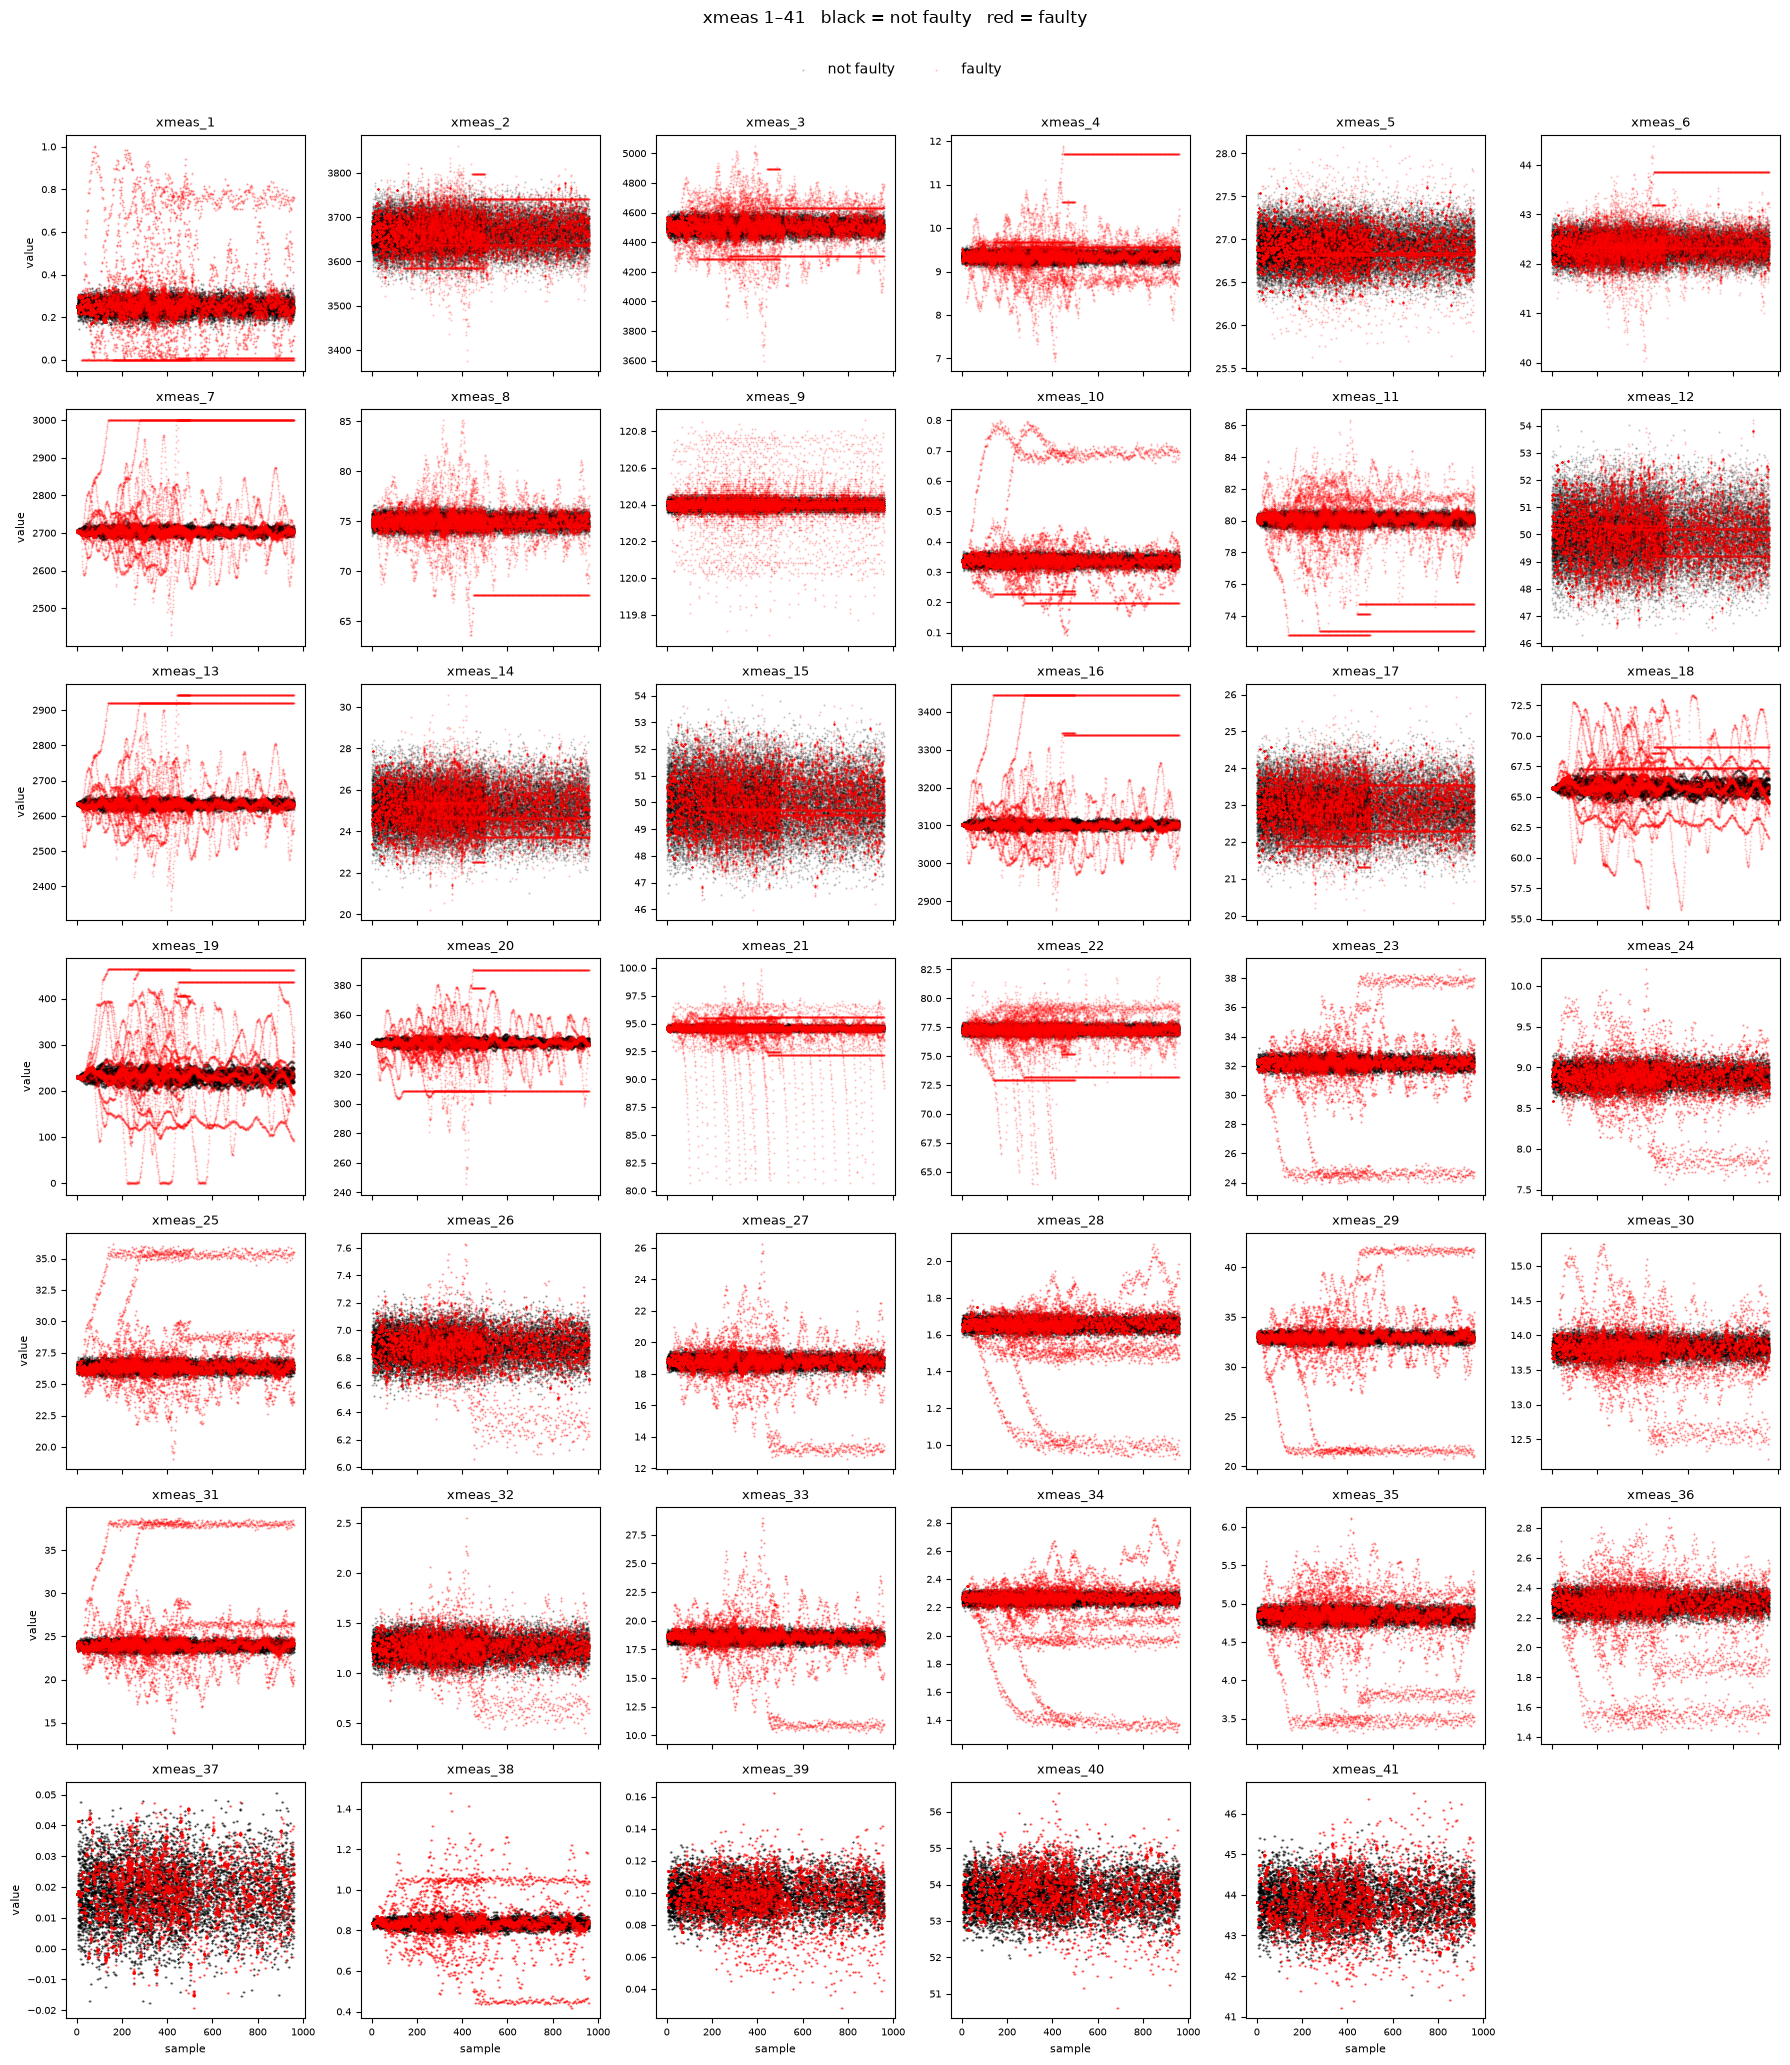

In [28]:
import matplotlib.pyplot as plt

XMEAS_COLS = [f"xmeas_{i}" for i in range(1, 42)]
N_HEALTHY_RUNS_PER_SOURCE = 20
RUN_LEN = {"train": 500, "test": 960}
GROUP_COLS = ["source", "faultNumber", "simulationRun"]
PLOT_COLS = ["source", "faultNumber", "simulationRun", "sample", *XMEAS_COLS]


def sample_healthy_runs(frame: pd.DataFrame, n_per_source: int = N_HEALTHY_RUNS_PER_SOURCE) -> pd.DataFrame:
    parts = []
    rng = 42
    for src, g in frame.groupby(frame["source"].astype(str), sort=True):
        ids = g["simulationRun"].drop_duplicates()
        take = ids.sample(n=min(n_per_source, len(ids)), random_state=rng)
        parts.append(g.loc[g["simulationRun"].isin(take), PLOT_COLS])
        log.info("plot healthy  source=%s  runs=%s  rows=%s", src, len(take), f"{len(parts[-1]):,}")
    return pd.concat(parts, ignore_index=True)


def load_faulty_plot_runs(path: Path = CSV_PATH, chunksize: int = CHUNKSIZE) -> pd.DataFrame:
    """First complete run per (source, faultNumber) for IDV 1–20."""
    wanted = {(src, f) for src in ("train", "test") for f in range(1, 21)}
    got: dict[tuple, pd.DataFrame] = {}
    buffer: dict[tuple, pd.DataFrame] = {}
    t0 = time.perf_counter()

    for i, chunk in enumerate(pd.read_csv(path, usecols=PLOT_COLS, chunksize=chunksize), start=1):
        faulty = chunk.loc[chunk["faultNumber"].astype(int).between(1, 20)]
        if faulty.empty:
            continue
        for key, g in faulty.groupby(GROUP_COLS, sort=False):
            src, fault = str(key[0]), int(key[1])
            pair = (src, fault)
            if pair in got:
                continue
            piece = g[PLOT_COLS].reset_index(drop=True)
            buf_key = (src, fault, int(key[2]))
            if buf_key in buffer:
                piece = pd.concat([buffer.pop(buf_key), piece], ignore_index=True)
            exp = RUN_LEN[src]
            if len(piece) >= exp:
                got[pair] = piece.iloc[:exp].copy()
                log.info("plot faulty   %s IDV(%s) run=%s  rows=%s", src, fault, int(key[2]), exp)
            else:
                buffer[buf_key] = piece
        if i == 1 or i % 8 == 0:
            log.info("plot scan    chunk=%s  collected=%s/40  elapsed=%.1fs", i, len(got), time.perf_counter() - t0)
        if len(got) == len(wanted):
            log.info("plot scan    all 40 faulty runs collected  elapsed=%.1fs", time.perf_counter() - t0)
            break

    missing = wanted - set(got)
    if missing:
        log.warning("missing faulty plot runs: %s", sorted(missing))
    return pd.concat(got.values(), ignore_index=True) if got else pd.DataFrame(columns=PLOT_COLS)


healthy_plot = sample_healthy_runs(df)
faulty_plot = load_faulty_plot_runs()
log.info("plot data   healthy_rows=%s  faulty_rows=%s", f"{len(healthy_plot):,}", f"{len(faulty_plot):,}")

fig, axes = plt.subplots(7, 6, figsize=(18, 20), sharex=True)
axes = axes.ravel()
for i, col in enumerate(XMEAS_COLS):
    ax = axes[i]
    ax.scatter(
        healthy_plot["sample"],
        healthy_plot[col],
        s=2,
        c="black",
        alpha=0.25,
        linewidths=0,
        label="not faulty" if i == 0 else None,
        rasterized=True,
    )
    ax.scatter(
        faulty_plot["sample"],
        faulty_plot[col],
        s=2,
        c="red",
        alpha=0.25,
        linewidths=0,
        label="faulty" if i == 0 else None,
        rasterized=True,
    )
    ax.set_title(col, fontsize=9)
    ax.tick_params(labelsize=7)
    if i % 6 == 0:
        ax.set_ylabel("value", fontsize=8)
    if i >= 36:
        ax.set_xlabel("sample", fontsize=8)

for j in range(len(XMEAS_COLS), len(axes)):
    axes[j].set_visible(False)

fig.legend(loc="upper center", ncols=2, frameon=False, fontsize=10, bbox_to_anchor=(0.5, 1.01))
fig.suptitle("xmeas 1–41   black = not faulty   red = faulty", y=1.03, fontsize=12)
fig.tight_layout()
plt.show()


## FPR and TPR together

The 41 plots overlap a lot: a rule that flags every faulty run (TPR 100%) often flags healthy runs too (FPR 100%). That is not separation.

| metric | what it is |
|---|---|
| **TPR** | share of **faulty** runs that fire (from the last CSV eval) |
| **FPR** | share of **healthy IDV(0)** runs that fire (from `df`) |
| **prefix FAR** | share of faulty runs that already fire **before onset** (not a real detection) |
| **Youden** | `TPR − FPR_test` — higher is better; 1.0 is perfect, 0 is useless |

We want **high TPR and low FPR**. `out_of_range` is the opposite problem (FPR ~0, TPR too low). Wide z-score is TPR ~100 with FPR ~100.


In [29]:
def run_level_rate(frame: pd.DataFrame, fn) -> tuple[float, int, int]:
    flags = fn(frame)
    hit = (
        frame.assign(_f=flags.to_numpy())
        .groupby(["source", "simulationRun"], sort=False)["_f"]
        .any()
    )
    return float(hit.mean()), int(hit.sum()), int(hit.size)


healthy = df.loc[df["faultNumber"].astype(int).eq(0)]
rows = []
for name, fn in CONDITIONS.items():
    fpr_all, n_all, n_all_tot = run_level_rate(healthy, fn)
    fpr_tr, n_tr, n_tr_tot = run_level_rate(healthy.loc[healthy["source"].astype(str).eq("train")], fn)
    fpr_te, n_te, n_te_tot = run_level_rate(healthy.loc[healthy["source"].astype(str).eq("test")], fn)
    tpr = prefix = None
    if "eval_scores" in globals() and name in eval_scores.index:
        tpr = float(eval_scores.loc[name, "percent"]) / 100.0
        if "prefix_percent" in eval_scores.columns:
            prefix = float(eval_scores.loc[name, "prefix_percent"]) / 100.0
    youden = (tpr - fpr_te) if tpr is not None else None
    rows.append(
        {
            "condition": name,
            "TPR": tpr,
            "FPR_train": fpr_tr,
            "FPR_test": fpr_te,
            "FPR_all": fpr_all,
            "prefix_FAR": prefix,
            "Youden_test": youden,
            "healthy_runs": f"{n_te}/{n_te_tot} test, {n_tr}/{n_tr_tot} train",
        }
    )
    log.info(
        "%s  TPR=%s  FPR_test=%.2f%%  Youden=%s",
        name,
        f"{100.0 * tpr:.1f}%" if tpr is not None else "run faulty eval first",
        100.0 * fpr_te,
        f"{youden:.3f}" if youden is not None else "n/a",
    )

fpr_tpr = pd.DataFrame(rows).set_index("condition")
print(fpr_tpr.to_string(float_format=lambda x: f"{x:8.4f}"))
fpr_tpr


10:55:31  INFO     out_of_range  TPR=85.5%  FPR_test=0.00%  Youden=0.855
10:55:31  INFO     zscore_2sd  TPR=100.0%  FPR_test=100.00%  Youden=0.000
10:55:32  INFO     zscore_3sd  TPR=100.0%  FPR_test=100.00%  Youden=0.000
10:55:32  INFO     zscore_4sd  TPR=93.5%  FPR_test=65.80%  Youden=0.277


                  TPR  FPR_train  FPR_test  FPR_all  prefix_FAR  Youden_test                 healthy_runs
condition                                                                                                
out_of_range   0.8553     0.0000    0.0000   0.0000      0.0000       0.8553      0/500 test, 0/500 train
zscore_2sd     1.0000     1.0000    1.0000   1.0000      1.0000       0.0000  500/500 test, 500/500 train
zscore_3sd     1.0000     1.0000    1.0000   1.0000      0.7340       0.0000  500/500 test, 500/500 train
zscore_4sd     0.9348     0.3960    0.6580   0.5270      0.0750       0.2768  329/500 test, 198/500 train


,TPR,FPR_train,FPR_test,FPR_all,prefix_FAR,Youden_test,healthy_runs
condition,,,,,,,
out_of_range,0.85525,0.000,0.000,0.000,0.000,0.85525,"0/500 test, 0/500 train"
zscore_2sd,1.00000,1.000,1.000,1.000,1.000,0.00000,"500/500 test, 500/500 train"
zscore_3sd,1.00000,1.000,1.000,1.000,0.734,0.00000,"500/500 test, 500/500 train"
zscore_4sd,0.93480,0.396,0.658,0.527,0.075,0.27680,"329/500 test, 198/500 train"


## PCA-SPE (relationships, not single sensors)

Fit **once** on healthy **train** IDV(0). Do not refit on test windows. A fault can sit inside every sensor’s `[min, max]` and still be wrong as a combination (pressure up, temperature down).

1. `StandardScaler` + `PCA(n_components=0.95)` on train-normal runs  
2. `SPE = ||x − x̂||²` reconstruction error  
3. Threshold = 99th percentile of SPE on a **held-out healthy validation** split of train runs  
4. Anomaly if `SPE > threshold`

Then score healthy IDV(0) (FPR) and all faulty runs (TPR) the same way as the z-score sheet: a run fires if **any** sample is over the limit.


In [30]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

SENSOR_COLS = [c for c in df.columns if str(c).startswith("xmeas_") or str(c).startswith("xmv_")]
RUN_LEN = {"train": 500, "test": 960}
PREFIX_LAST = {"train": 20, "test": 160}
GROUP_COLS = ["source", "faultNumber", "simulationRun"]
PCA_VAR = 0.95
PCA_Q = 0.99
PCA_VAL_FRAC = 0.20
PCA_SPLIT_SEED = 42

train_idv0 = df.loc[df["source"].astype(str).eq("train") & df["faultNumber"].astype(int).eq(0)]
train_runs = train_idv0["simulationRun"].drop_duplicates().to_numpy()
rng = np.random.default_rng(PCA_SPLIT_SEED)
train_runs = rng.permutation(train_runs)
n_val = max(1, int(len(train_runs) * PCA_VAL_FRAC))
val_run_ids = set(train_runs[:n_val])
fit_run_ids = set(train_runs[n_val:])
X_fit = train_idv0.loc[train_idv0["simulationRun"].isin(fit_run_ids), SENSOR_COLS]
X_val = train_idv0.loc[train_idv0["simulationRun"].isin(val_run_ids), SENSOR_COLS]

scaler = StandardScaler()
X_fit_scaled = scaler.fit_transform(X_fit)
pca = PCA(n_components=PCA_VAR)
pca.fit(X_fit_scaled)

def spe_values(frame: pd.DataFrame) -> np.ndarray:
    x = scaler.transform(frame[SENSOR_COLS])
    x_hat = pca.inverse_transform(pca.transform(x))
    return ((x - x_hat) ** 2).sum(axis=1)


val_spe = spe_values(X_val)
spe_threshold = float(np.quantile(val_spe, PCA_Q))
log.info(
    "PCA-SPE fit  train_runs=%s  val_runs=%s  sensors=%s  n_comp=%s  var=%.3f  thr(q=%.2f)=%.4f",
    len(fit_run_ids),
    len(val_run_ids),
    len(SENSOR_COLS),
    pca.n_components_,
    float(pca.explained_variance_ratio_.sum()),
    PCA_Q,
    spe_threshold,
)


def flags_pca_spe(frame: pd.DataFrame) -> pd.Series:
    """1 if the process state is outside the normal PCA envelope (SPE)."""
    return pd.Series(spe_values(frame) > spe_threshold, index=frame.index)


if "CONDITIONS" in globals():
    CONDITIONS["pca_spe"] = flags_pca_spe
    log.info("CONDITIONS now %s", list(CONDITIONS))


def run_hits(frame: pd.DataFrame, fn) -> pd.Series:
    flags = fn(frame)
    return (
        frame.assign(_f=np.asarray(flags))
        .groupby(["source", "simulationRun"], sort=False)["_f"]
        .any()
    )


healthy = df.loc[df["faultNumber"].astype(int).eq(0)]
pca_fpr = {}
for src, g in healthy.groupby(healthy["source"].astype(str), sort=True):
    hits = run_hits(g, flags_pca_spe)
    pca_fpr[src] = (float(hits.mean()), int(hits.sum()), int(hits.size))
    log.info("PCA-SPE FPR  healthy %s  %s/%s  (%.2f%%)", src, hits.sum(), hits.size, 100.0 * hits.mean())


def eval_pca_faulty(path: Path = CSV_PATH, chunksize: int = CHUNKSIZE) -> dict:
    n_runs = 0
    n_true = 0
    n_prefix = 0
    n_runs_src = {"train": 0, "test": 0}
    n_true_src = {"train": 0, "test": 0}
    n_prefix_src = {"train": 0, "test": 0}
    buffer: dict[tuple, pd.DataFrame] = {}
    t0 = time.perf_counter()
    usecols = GROUP_COLS + ["sample"] + SENSOR_COLS

    def consume(run: pd.DataFrame) -> None:
        nonlocal n_runs, n_true, n_prefix
        src = str(run["source"].iloc[0])
        flags = flags_pca_spe(run)
        hit = bool(flags.any())
        pre = run.loc[run["sample"].astype(int) <= PREFIX_LAST[src]]
        pre_hit = bool(flags_pca_spe(pre).any()) if len(pre) else False
        n_runs += 1
        n_true += int(hit)
        n_prefix += int(pre_hit)
        n_runs_src[src] += 1
        n_true_src[src] += int(hit)
        n_prefix_src[src] += int(pre_hit)

    log.info("start PCA-SPE faulty eval")
    for i, chunk in enumerate(pd.read_csv(path, usecols=usecols, chunksize=chunksize), start=1):
        faulty = chunk.loc[chunk["faultNumber"].astype(int).ne(0)]
        if faulty.empty:
            if i == 1 or i % 8 == 0:
                log.info("chunk %03d  runs=%s  elapsed=%.1fs", i, n_runs, time.perf_counter() - t0)
            continue
        for key, g in faulty.groupby(GROUP_COLS, sort=False):
            src = str(key[0])
            piece = g.reset_index(drop=True)
            if key in buffer:
                piece = pd.concat([buffer.pop(key), piece], ignore_index=True)
            exp = RUN_LEN[src]
            while len(piece) >= exp:
                consume(piece.iloc[:exp].copy())
                piece = piece.iloc[exp:].reset_index(drop=True)
            if len(piece):
                buffer[key] = piece
        if i == 1 or i % 8 == 0:
            log.info("chunk %03d  runs=%s  buffered=%s  elapsed=%.1fs", i, n_runs, len(buffer), time.perf_counter() - t0)

    for leftover in buffer.values():
        consume(leftover)

    log.info("done PCA-SPE faulty  runs=%s  TPR=%.2f%%  prefix=%.2f%%  elapsed=%.1fs", n_runs, 100.0 * n_true / n_runs, 100.0 * n_prefix / n_runs, time.perf_counter() - t0)
    for src in ("train", "test"):
        n = n_runs_src[src]
        log.info("  %s  TPR %s/%s (%.2f%%)  prefix %s/%s (%.2f%%)", src, n_true_src[src], n, 100.0 * n_true_src[src] / n, n_prefix_src[src], n, 100.0 * n_prefix_src[src] / n)
    return {
        "n_true": n_true,
        "n_windows": n_runs,
        "percent": 100.0 * n_true / n_runs,
        "n_prefix": n_prefix,
        "prefix_percent": 100.0 * n_prefix / n_runs,
    }


pca_faulty = eval_pca_faulty()
if "eval_scores" in globals():
    eval_scores.loc["pca_spe"] = pca_faulty
    log.info("eval_scores updated with pca_spe")

fpr_te = pca_fpr["test"][0]
tpr = pca_faulty["percent"] / 100.0
pca_row = {
    "TPR": tpr,
    "FPR_train": pca_fpr["train"][0],
    "FPR_test": fpr_te,
    "FPR_all": run_hits(healthy, flags_pca_spe).mean(),
    "prefix_FAR": pca_faulty["prefix_percent"] / 100.0,
    "Youden_test": tpr - fpr_te,
    "healthy_runs": f"{pca_fpr['test'][1]}/{pca_fpr['test'][2]} test, {pca_fpr['train'][1]}/{pca_fpr['train'][2]} train",
}

if "fpr_tpr" in globals():
    fpr_tpr.loc["pca_spe"] = pca_row
else:
    fpr_tpr = pd.DataFrame([pca_row], index=pd.Index(["pca_spe"], name="condition"))

print("\ncomparison (higher Youden_test is better)")
print(fpr_tpr.sort_values("Youden_test", ascending=False).to_string(float_format=lambda x: f"{x:8.4f}"))
fpr_tpr.sort_values("Youden_test", ascending=False)


11:03:48  INFO     chunk 008  runs=3500  buffered=0  elapsed=8.0s
11:03:56  INFO     chunk 016  runs=7500  buffered=0  elapsed=16.5s
11:04:03  INFO     chunk 024  runs=10281  buffered=1  elapsed=23.2s
11:04:09  INFO     chunk 032  runs=12364  buffered=1  elapsed=29.2s
11:04:15  INFO     chunk 040  runs=14447  buffered=1  elapsed=35.3s
11:04:21  INFO     chunk 048  runs=16531  buffered=1  elapsed=41.2s
11:04:27  INFO     chunk 056  runs=18614  buffered=1  elapsed=47.0s
11:04:30  INFO     done PCA-SPE faulty  runs=20000  TPR=99.90%  prefix=37.20%  elapsed=50.8s
11:04:30  INFO       train  TPR 9980/10000 (99.80%)  prefix 900/10000 (9.00%)
11:04:30  INFO       test  TPR 10000/10000 (100.00%)  prefix 6540/10000 (65.40%)
11:04:30  INFO     eval_scores updated with pca_spe



comparison (higher Youden_test is better)
                  TPR  FPR_train  FPR_test  FPR_all  prefix_FAR  Youden_test                 healthy_runs
condition                                                                                                
out_of_range   0.8553     0.0000    0.0000   0.0000      0.0000       0.8553      0/500 test, 0/500 train
zscore_4sd     0.9348     0.3960    0.6580   0.5270      0.0750       0.2768  329/500 test, 198/500 train
zscore_2sd     1.0000     1.0000    1.0000   1.0000      1.0000       0.0000  500/500 test, 500/500 train
zscore_3sd     1.0000     1.0000    1.0000   1.0000      0.7340       0.0000  500/500 test, 500/500 train
pca_spe        0.9990     0.9760    1.0000   0.9880      0.3720      -0.0010  500/500 test, 488/500 train


,TPR,FPR_train,FPR_test,FPR_all,prefix_FAR,Youden_test,healthy_runs
condition,,,,,,,
out_of_range,0.85525,0.000,0.000,0.000,0.000,0.85525,"0/500 test, 0/500 train"
zscore_4sd,0.93480,0.396,0.658,0.527,0.075,0.27680,"329/500 test, 198/500 train"
zscore_2sd,1.00000,1.000,1.000,1.000,1.000,0.00000,"500/500 test, 500/500 train"
zscore_3sd,1.00000,1.000,1.000,1.000,0.734,0.00000,"500/500 test, 500/500 train"
pca_spe,0.99900,0.976,1.000,0.988,0.372,-0.00100,"500/500 test, 488/500 train"


## Correlation change

Sensors that move together when healthy can **decouple** in a fault, even if each value stays inside `[min, max]`.

1. `R_normal = corr(X_train_normal)` — fit once on the same train-IDV(0) split as PCA (do not refit on test)  
2. Rolling window of **50** samples: `R_t = corr(window)`  
3. `C_t = ||R_t − R_normal||_F`  
4. Threshold = 99th percentile of `C_t` on healthy **validation** runs  
5. A run fires if any window score is above the threshold  

Scores are computed every 10 samples after the window is full (runtime). Train prefix is only 20 samples, so a 50-sample window cannot sit entirely before train onset — prefix FAR is meaningful on **test** (160 ≥ 50).


In [ ]:
import numpy as np

CORR_WINDOW = 50
CORR_STEP = 10
CORR_Q = 0.99
RUN_LEN = {"train": 500, "test": 960}
PREFIX_LAST = {"train": 20, "test": 160}
GROUP_COLS = ["source", "faultNumber", "simulationRun"]
CORR_SENSORS = [c for c in df.columns if str(c).startswith("xmeas_") or str(c).startswith("xmv_")]

train_idv0 = df.loc[df["source"].astype(str).eq("train") & df["faultNumber"].astype(int).eq(0)].copy()
if "fit_run_ids" not in globals() or "val_run_ids" not in globals():
    _ids = train_idv0["simulationRun"].drop_duplicates().to_numpy()
    _rng = np.random.default_rng(42)
    _ids = _rng.permutation(_ids)
    _n_val = max(1, int(len(_ids) * 0.20))
    val_run_ids = set(_ids[:_n_val])
    fit_run_ids = set(_ids[_n_val:])

X_fit_corr = train_idv0.loc[train_idv0["simulationRun"].isin(fit_run_ids), CORR_SENSORS]
R_normal = np.nan_to_num(X_fit_corr.corr().to_numpy(dtype=np.float64), nan=0.0)


def window_corr_score(window_X: np.ndarray) -> float:
    R = np.corrcoef(window_X, rowvar=False)
    R = np.nan_to_num(R, nan=0.0)
    if R.shape != R_normal.shape:
        raise ValueError(f"corr shape {R.shape} != R_normal {R_normal.shape}")
    return float(np.linalg.norm(R - R_normal, ord="fro"))


def correlation_scores(run: pd.DataFrame) -> pd.Series:
    missing = [c for c in CORR_SENSORS if c not in run.columns]
    if missing:
        raise KeyError(f"correlation run is missing columns {missing[:5]}… — use full df rows, not the xmeas-only plot sample")
    ordered = run.sort_values("sample", kind="mergesort")
    X = ordered[CORR_SENSORS].to_numpy(dtype=np.float64)
    scores = np.full(len(ordered), np.nan)
    start = CORR_WINDOW - 1
    if len(X) <= start:
        return pd.Series(scores, index=ordered.index)
    for i in range(start, len(X), CORR_STEP):
        scores[i] = window_corr_score(X[i - CORR_WINDOW + 1 : i + 1])
    return pd.Series(scores, index=ordered.index).reindex(run.index)


def flags_corr_change(frame: pd.DataFrame) -> pd.Series:
    """1 if the rolling correlation structure left the normal envelope."""
    if frame[["source", "simulationRun"]].drop_duplicates().shape[0] > 1:
        out = pd.Series(False, index=frame.index)
        for _, g in frame.groupby(["source", "simulationRun"], sort=False):
            out.loc[g.index] = flags_corr_change(g).to_numpy()
        return out
    return correlation_scores(frame).gt(corr_threshold).fillna(False)


val_scores = []
for _, g in train_idv0.loc[train_idv0["simulationRun"].isin(val_run_ids)].groupby("simulationRun", sort=False):
    s = correlation_scores(g).dropna()
    if len(s):
        val_scores.append(s.to_numpy())
val_scores = np.concatenate(val_scores) if val_scores else np.array([0.0])
corr_threshold = float(np.quantile(val_scores, CORR_Q))
log.info(
    "corr-change fit  window=%s  step=%s  sensors=%s  R=%s  val_windows=%s  thr(q=%.2f)=%.4f",
    CORR_WINDOW,
    CORR_STEP,
    len(CORR_SENSORS),
    R_normal.shape,
    f"{len(val_scores):,}",
    CORR_Q,
    corr_threshold,
)

if "CONDITIONS" in globals():
    CONDITIONS["corr_change"] = flags_corr_change
    log.info("CONDITIONS now %s", list(CONDITIONS))


def _run_any(frame: pd.DataFrame, fn) -> pd.Series:
    return (
        frame.assign(_f=np.asarray(fn(frame)))
        .groupby(["source", "simulationRun"], sort=False)["_f"]
        .any()
    )


healthy = df.loc[df["faultNumber"].astype(int).eq(0)]
corr_fpr = {}
for src, g in healthy.groupby(healthy["source"].astype(str), sort=True):
    hits = _run_any(g, flags_corr_change)
    corr_fpr[src] = (float(hits.mean()), int(hits.sum()), int(hits.size))
    log.info("corr-change FPR  healthy %s  %s/%s  (%.2f%%)", src, hits.sum(), hits.size, 100.0 * hits.mean())


def eval_corr_faulty(path: Path = CSV_PATH, chunksize: int = CHUNKSIZE) -> dict:
    n_runs = n_true = n_prefix = 0
    n_runs_src = {"train": 0, "test": 0}
    n_true_src = {"train": 0, "test": 0}
    n_prefix_src = {"train": 0, "test": 0}
    buffer: dict[tuple, pd.DataFrame] = {}
    t0 = time.perf_counter()
    usecols = list(dict.fromkeys(GROUP_COLS + ["sample"] + CORR_SENSORS))

    def consume(run: pd.DataFrame) -> None:
        nonlocal n_runs, n_true, n_prefix
        src = str(run["source"].iloc[0])
        scores = correlation_scores(run)
        flags = scores.gt(corr_threshold).fillna(False)
        hit = bool(flags.any())
        ends = run.loc[flags.to_numpy(), "sample"].astype(int) if hit else pd.Series(dtype=int)
        pre_hit = bool((ends <= PREFIX_LAST[src]).any()) if len(ends) else False
        n_runs += 1
        n_true += int(hit)
        n_prefix += int(pre_hit)
        n_runs_src[src] += 1
        n_true_src[src] += int(hit)
        n_prefix_src[src] += int(pre_hit)

    log.info("start corr-change faulty eval")
    for i, chunk in enumerate(pd.read_csv(path, usecols=usecols, chunksize=chunksize), start=1):
        faulty = chunk.loc[chunk["faultNumber"].astype(int).ne(0)]
        if faulty.empty:
            if i == 1 or i % 8 == 0:
                log.info("chunk %03d  runs=%s  elapsed=%.1fs", i, n_runs, time.perf_counter() - t0)
            continue
        for key, g in faulty.groupby(GROUP_COLS, sort=False):
            src = str(key[0])
            piece = g.reset_index(drop=True)
            if key in buffer:
                piece = pd.concat([buffer.pop(key), piece], ignore_index=True)
            exp = RUN_LEN[src]
            while len(piece) >= exp:
                consume(piece.iloc[:exp].copy())
                piece = piece.iloc[exp:].reset_index(drop=True)
            if len(piece):
                buffer[key] = piece
        if i == 1 or i % 8 == 0:
            log.info("chunk %03d  runs=%s  buffered=%s  elapsed=%.1fs", i, n_runs, len(buffer), time.perf_counter() - t0)
    for leftover in buffer.values():
        consume(leftover)

    log.info(
        "done corr-change faulty  runs=%s  TPR=%.2f%%  prefix=%.2f%%  elapsed=%.1fs",
        n_runs, 100.0 * n_true / max(n_runs, 1), 100.0 * n_prefix / max(n_runs, 1), time.perf_counter() - t0,
    )
    for src in ("train", "test"):
        n = n_runs_src[src]
        if n == 0:
            continue
        log.info(
            "  %s  TPR %s/%s (%.2f%%)  prefix %s/%s (%.2f%%)",
            src, n_true_src[src], n, 100.0 * n_true_src[src] / n, n_prefix_src[src], n, 100.0 * n_prefix_src[src] / n,
        )
    return {
        "n_true": n_true,
        "n_windows": n_runs,
        "percent": 100.0 * n_true / max(n_runs, 1),
        "n_prefix": n_prefix,
        "prefix_percent": 100.0 * n_prefix / max(n_runs, 1),
    }


corr_faulty = eval_corr_faulty()
if "eval_scores" in globals():
    eval_scores.loc["corr_change"] = corr_faulty

fpr_te = corr_fpr["test"][0]
tpr = corr_faulty["percent"] / 100.0
corr_row = {
    "TPR": tpr,
    "FPR_train": corr_fpr["train"][0],
    "FPR_test": fpr_te,
    "FPR_all": float(_run_any(healthy, flags_corr_change).mean()),
    "prefix_FAR": corr_faulty["prefix_percent"] / 100.0,
    "Youden_test": tpr - fpr_te,
    "healthy_runs": f"{corr_fpr['test'][1]}/{corr_fpr['test'][2]} test, {corr_fpr['train'][1]}/{corr_fpr['train'][2]} train",
}
if "fpr_tpr" in globals():
    fpr_tpr.loc["corr_change"] = corr_row
else:
    fpr_tpr = pd.DataFrame([corr_row], index=pd.Index(["corr_change"], name="condition"))

print("\ncomparison (higher Youden_test is better)")
print(fpr_tpr.sort_values("Youden_test", ascending=False).to_string(float_format=lambda x: f"{x:8.4f}"))
fpr_tpr.sort_values("Youden_test", ascending=False)


11:09:25  INFO     corr-change fit  window=50  step=10  sensors=52  R=(52, 52)  val_windows=4,600  thr(q=0.99)=13.2523
11:09:25  INFO     CONDITIONS now ['out_of_range', 'zscore_2sd', 'zscore_3sd', 'zscore_4sd', 'pca_spe', 'corr_change']
11:09:27  INFO     corr-change FPR  healthy test  229/500  (45.80%)
11:09:28  INFO     corr-change FPR  healthy train  129/500  (25.80%)
11:09:28  INFO     start corr-change faulty eval
11:09:28  INFO     chunk 001  runs=0  elapsed=0.3s
/Users/ob/Projects/hackathon_csv/data_processing/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/ob/Projects/hackathon_csv/data_processing/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/ob/Projects/hackathon_csv/data_processing/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3036: Runtim

## Correlation-change visualization

`C_t` over time for one healthy test run vs one faulty test run. The dashed line is the validation threshold. A real fault should stay quiet, then jump.


In [ ]:
import matplotlib.pyplot as plt

healthy_test_runs = df.loc[df["source"].astype(str).eq("test") & df["faultNumber"].astype(int).eq(0)]
h_run_id = int(healthy_test_runs["simulationRun"].drop_duplicates().iloc[0])
healthy_ex = healthy_test_runs.loc[healthy_test_runs["simulationRun"].eq(h_run_id)].sort_values("sample")
h_scores = correlation_scores(healthy_ex)

# Stream one full test IDV(1) run with the same columns used to fit R_normal (xmeas + xmv).
# Do not reuse faulty_plot — that table is xmeas-only.
usecols = list(dict.fromkeys(GROUP_COLS + ["sample"] + CORR_SENSORS))
buf = []
for chunk in pd.read_csv(CSV_PATH, usecols=usecols, chunksize=CHUNKSIZE):
    hit = chunk.loc[
        chunk["source"].astype(str).eq("test")
        & chunk["faultNumber"].astype(int).eq(1)
        & chunk["simulationRun"].astype(int).eq(1)
    ]
    if len(hit):
        buf.append(hit)
        if sum(len(x) for x in buf) >= RUN_LEN["test"]:
            break
f_ex = pd.concat(buf, ignore_index=True).sort_values("sample").iloc[: RUN_LEN["test"]]
f_scores = correlation_scores(f_ex)
onset = PREFIX_LAST["test"]

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, sharey=True)
for ax, title, scores, ex, color in (
    (axes[0], f"healthy test  run={h_run_id}", h_scores, healthy_ex, "black"),
    (axes[1], f"faulty test  IDV({int(f_ex['faultNumber'].iloc[0])}) run={int(f_ex['simulationRun'].iloc[0])}", f_scores, f_ex, "crimson"),
):
    pts = pd.DataFrame({"sample": ex["sample"].to_numpy(), "C": scores.to_numpy()}).dropna()
    ax.plot(pts["sample"], pts["C"], lw=1.4, color=color)
    ax.axhline(corr_threshold, color="C1", ls="--", lw=1, label=f"threshold q={CORR_Q:.0%}")
    ax.axvline(onset, color="C3", ls=":", lw=1.2, label=f"onset sample {onset}")
    ax.set_ylabel(r"$C_t=\|R_t-R_{normal}\|_F$")
    ax.set_title(title)
    ax.legend(loc="upper left", fontsize=8)
axes[1].set_xlabel("sample")
fig.suptitle("Correlation-structure change")
fig.tight_layout()
plt.show()

print(f"healthy max C_t={h_scores.max():.3f}  faulty max C_t={f_scores.max():.3f}  threshold={corr_threshold:.3f}")


KeyError: "['xmv_1', 'xmv_2', 'xmv_3', 'xmv_4', 'xmv_5', 'xmv_6', 'xmv_7', 'xmv_8', 'xmv_9', 'xmv_10', 'xmv_11'] not in index"

## Persistence: 5 of the last 8 z-score hits

A single `|z| > k` spike is too noisy (2σ/3σ flagged every healthy run). Require **5 of the last 8 samples** to be anomalous before the alarm goes on.

A sample is anomalous if **any** sensor is outside `k` sd of the IDV(0) mean (`k = 2, 3, 4`). The first 7 samples of a run cannot alarm (window not full). Same run lengths as before (train 500, test 960). Results go on the FPR/TPR sheet as `persist_2sd`, `persist_3sd`, `persist_4sd`.


In [ ]:
PERSIST_NEED = 5
PERSIST_WIN = 8
PERSIST_KS = (2, 3, 4)
RUN_LEN = {"train": 500, "test": 960}
PREFIX_LAST = {"train": 20, "test": 160}
GROUP_COLS = ["source", "faultNumber", "simulationRun"]
SENSOR_COLS = [c for c in df.columns if str(c).startswith("xmeas_") or str(c).startswith("xmv_")]

if "flags_zscore" not in globals():
    _lo = stats.loc[SENSOR_COLS, "mean"]
    _sd = stats.loc[SENSOR_COLS, "sd"].clip(lower=1e-12)

    def flags_zscore(frame: pd.DataFrame, k: float) -> pd.Series:
        z = (frame[SENSOR_COLS] - _lo).abs() / _sd
        return z.gt(k).any(axis=1)


def flags_persist_ksd(frame: pd.DataFrame, k: float, need: int = PERSIST_NEED, win: int = PERSIST_WIN) -> pd.Series:
    """Alarm if `need` of the last `win` samples are |z|>k on any sensor."""

    def one_run(g: pd.DataFrame) -> pd.Series:
        ordered = g.sort_values("sample", kind="mergesort")
        raw = flags_zscore(ordered, k).astype(int)
        rolled = raw.rolling(win, min_periods=win).sum()
        return (rolled >= need).reindex(g.index).fillna(False)

    if frame[["source", "simulationRun"]].drop_duplicates().shape[0] > 1:
        out = pd.Series(False, index=frame.index)
        for _, g in frame.groupby(["source", "simulationRun"], sort=False):
            out.loc[g.index] = one_run(g)
        return out
    return one_run(frame)


def flags_persist_2sd(frame: pd.DataFrame) -> pd.Series:
    return flags_persist_ksd(frame, 2)


def flags_persist_3sd(frame: pd.DataFrame) -> pd.Series:
    return flags_persist_ksd(frame, 3)


def flags_persist_4sd(frame: pd.DataFrame) -> pd.Series:
    return flags_persist_ksd(frame, 4)


if "CONDITIONS" in globals():
    CONDITIONS["persist_2sd"] = flags_persist_2sd
    CONDITIONS["persist_3sd"] = flags_persist_3sd
    CONDITIONS["persist_4sd"] = flags_persist_4sd
    log.info("CONDITIONS now %s", list(CONDITIONS))


def _run_any(frame: pd.DataFrame, fn) -> pd.Series:
    return (
        frame.assign(_f=np.asarray(fn(frame)))
        .groupby(["source", "simulationRun"], sort=False)["_f"]
        .any()
    )


healthy = df.loc[df["faultNumber"].astype(int).eq(0)]
persist_fpr = {}
for k in PERSIST_KS:
    name = f"persist_{k}sd"
    persist_fpr[name] = {}
    fn = lambda frame, k=k: flags_persist_ksd(frame, k)
    for src, g in healthy.groupby(healthy["source"].astype(str), sort=True):
        hits = _run_any(g, fn)
        persist_fpr[name][src] = (float(hits.mean()), int(hits.sum()), int(hits.size))
        log.info("%s FPR  healthy %s  %s/%s  (%.2f%%)", name, src, hits.sum(), hits.size, 100.0 * hits.mean())


def eval_persist_faulty(path: Path = CSV_PATH, chunksize: int = CHUNKSIZE) -> dict[str, dict]:
    stats_out = {
        f"persist_{k}sd": {"n_runs": 0, "n_true": 0, "n_prefix": 0, "src_runs": {"train": 0, "test": 0}, "src_true": {"train": 0, "test": 0}, "src_pre": {"train": 0, "test": 0}}
        for k in PERSIST_KS
    }
    buffer: dict[tuple, pd.DataFrame] = {}
    t0 = time.perf_counter()
    usecols = GROUP_COLS + ["sample"] + SENSOR_COLS

    def consume(run: pd.DataFrame) -> None:
        src = str(run["source"].iloc[0])
        for k in PERSIST_KS:
            name = f"persist_{k}sd"
            flags = flags_persist_ksd(run, k)
            hit = bool(flags.any())
            ends = run.loc[np.asarray(flags), "sample"].astype(int) if hit else pd.Series(dtype=int)
            pre = bool((ends <= PREFIX_LAST[src]).any()) if len(ends) else False
            rec = stats_out[name]
            rec["n_runs"] += 1
            rec["n_true"] += int(hit)
            rec["n_prefix"] += int(pre)
            rec["src_runs"][src] += 1
            rec["src_true"][src] += int(hit)
            rec["src_pre"][src] += int(pre)

    log.info("start persist 5-of-8 faulty eval  k=%s", list(PERSIST_KS))
    for i, chunk in enumerate(pd.read_csv(path, usecols=usecols, chunksize=chunksize), start=1):
        faulty = chunk.loc[chunk["faultNumber"].astype(int).ne(0)]
        if faulty.empty:
            if i == 1 or i % 8 == 0:
                log.info("chunk %03d  runs=%s  elapsed=%.1fs", i, stats_out["persist_2sd"]["n_runs"], time.perf_counter() - t0)
            continue
        for key, g in faulty.groupby(GROUP_COLS, sort=False):
            src = str(key[0])
            piece = g.reset_index(drop=True)
            if key in buffer:
                piece = pd.concat([buffer.pop(key), piece], ignore_index=True)
            exp = RUN_LEN[src]
            while len(piece) >= exp:
                consume(piece.iloc[:exp].copy())
                piece = piece.iloc[exp:].reset_index(drop=True)
            if len(piece):
                buffer[key] = piece
        if i == 1 or i % 8 == 0:
            log.info("chunk %03d  runs=%s  buffered=%s  elapsed=%.1fs", i, stats_out["persist_2sd"]["n_runs"], len(buffer), time.perf_counter() - t0)
    for leftover in buffer.values():
        consume(leftover)

    rows = {}
    for name, rec in stats_out.items():
        n = rec["n_runs"]
        rows[name] = {
            "n_true": rec["n_true"],
            "n_windows": n,
            "percent": 100.0 * rec["n_true"] / n,
            "n_prefix": rec["n_prefix"],
            "prefix_percent": 100.0 * rec["n_prefix"] / n,
        }
        log.info(
            "done %s  TPR=%.2f%%  prefix=%.2f%%",
            name, rows[name]["percent"], rows[name]["prefix_percent"],
        )
        for src in ("train", "test"):
            ns = rec["src_runs"][src]
            log.info(
                "  %s  TPR %s/%s (%.2f%%)  prefix %s/%s (%.2f%%)",
                src, rec["src_true"][src], ns, 100.0 * rec["src_true"][src] / ns,
                rec["src_pre"][src], ns, 100.0 * rec["src_pre"][src] / ns,
            )
    log.info("persist elapsed=%.1fs", time.perf_counter() - t0)
    return rows


persist_faulty = eval_persist_faulty()

if "fpr_tpr" not in globals():
    fpr_tpr = pd.DataFrame(columns=["TPR", "FPR_train", "FPR_test", "FPR_all", "prefix_FAR", "Youden_test", "healthy_runs"])

for k in PERSIST_KS:
    name = f"persist_{k}sd"
    if "eval_scores" in globals():
        eval_scores.loc[name] = persist_faulty[name]
    tpr = persist_faulty[name]["percent"] / 100.0
    fpr_tr = persist_fpr[name]["train"][0]
    fpr_te = persist_fpr[name]["test"][0]
    fpr_tpr.loc[name] = {
        "TPR": tpr,
        "FPR_train": fpr_tr,
        "FPR_test": fpr_te,
        "FPR_all": float(_run_any(healthy, lambda frame, k=k: flags_persist_ksd(frame, k)).mean()),
        "prefix_FAR": persist_faulty[name]["prefix_percent"] / 100.0,
        "Youden_test": tpr - fpr_te,
        "healthy_runs": (
            f"{persist_fpr[name]['test'][1]}/{persist_fpr[name]['test'][2]} test, "
            f"{persist_fpr[name]['train'][1]}/{persist_fpr[name]['train'][2]} train"
        ),
    }

print("\ncomparison (higher Youden_test is better)")
print(fpr_tpr.sort_values("Youden_test", ascending=False).to_string(float_format=lambda x: f"{x:8.4f}"))
fpr_tpr.sort_values("Youden_test", ascending=False)


## CVA (canonical variate analysis)

Unsupervised, like PCA, but **dynamic**: it models how the last few samples predict the next few. Fit on healthy **train** IDV(0) only.

- Past / future lag vectors → canonical states  
- Alarm if **T²** (state) **or SPE** (residual) exceeds the 99th percentile on held-out healthy validation  
- A run fires if any time step alarms  

This is for “the process trajectory left the normal dynamic subspace,” not a single sensor spike.


In [ ]:
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.preprocessing import StandardScaler

CVA_LAGS = 3
CVA_Q = 0.99
CVA_VAR = 0.95
RUN_LEN = {"train": 500, "test": 960}
PREFIX_LAST = {"train": 20, "test": 160}
GROUP_COLS = ["source", "faultNumber", "simulationRun"]
CVA_SENSORS = [c for c in df.columns if str(c).startswith("xmeas_") or str(c).startswith("xmv_")]

train_idv0 = df.loc[df["source"].astype(str).eq("train") & df["faultNumber"].astype(int).eq(0)].copy()
if "fit_run_ids" not in globals() or "val_run_ids" not in globals():
    _ids = train_idv0["simulationRun"].drop_duplicates().to_numpy()
    _rng = np.random.default_rng(42)
    _ids = _rng.permutation(_ids)
    _n_val = max(1, int(len(_ids) * 0.20))
    val_run_ids = set(_ids[:_n_val])
    fit_run_ids = set(_ids[_n_val:])

cva_scaler = StandardScaler()
cva_scaler.fit(train_idv0.loc[train_idv0["simulationRun"].isin(fit_run_ids), CVA_SENSORS])


def _lag_pairs(X: np.ndarray, lags: int) -> tuple[np.ndarray, np.ndarray]:
    n, p = X.shape
    n_pairs = n - 2 * lags + 1
    if n_pairs <= 0:
        return np.zeros((0, p * lags)), np.zeros((0, p * lags))
    windows = sliding_window_view(X, (lags, p))[:, 0]
    past = windows[:n_pairs].reshape(n_pairs, -1)
    future = windows[lags : lags + n_pairs].reshape(n_pairs, -1)
    return past.astype(np.float64, copy=False), future.astype(np.float64, copy=False)


def _cov(A: np.ndarray) -> np.ndarray:
    A = A - A.mean(axis=0, keepdims=True)
    return (A.T @ A) / max(len(A) - 1, 1)


def _inv_sqrt(S: np.ndarray, eps: float = 1e-10) -> np.ndarray:
    w, V = np.linalg.eigh(S)
    w = np.clip(w, 0, None)
    cutoff = eps * (float(w.max()) if w.size else 1.0)
    inv = np.zeros_like(w)
    ok = w > cutoff
    inv[ok] = 1.0 / np.sqrt(w[ok])
    return (V * inv) @ V.T


P_fit, F_fit = [], []
for _, g in train_idv0.loc[train_idv0["simulationRun"].isin(fit_run_ids)].groupby("simulationRun", sort=False):
    X = cva_scaler.transform(g.sort_values("sample")[CVA_SENSORS])
    p, f = _lag_pairs(X, CVA_LAGS)
    if len(p):
        P_fit.append(p)
        F_fit.append(f)
P_fit = np.concatenate(P_fit, axis=0)
F_fit = np.concatenate(F_fit, axis=0)
cva_mean_p = P_fit.mean(axis=0)
P0, F0 = P_fit - cva_mean_p, F_fit - F_fit.mean(axis=0)
Spp, Sff, Spf = _cov(P0), _cov(F0), (P0.T @ F0) / max(len(P0) - 1, 1)
ipp, iff = _inv_sqrt(Spp), _inv_sqrt(Sff)
H = ipp @ Spf @ iff
U, s, _Vt = np.linalg.svd(H, full_matrices=False)
energy = np.cumsum(s**2) / max((s**2).sum(), 1e-12)
cva_k = int(np.searchsorted(energy, CVA_VAR) + 1)
cva_k = min(max(cva_k, 1), len(s))
cva_U = U[:, :cva_k]
cva_ipp = ipp
Z_fit = (P0 @ ipp) @ cva_U
cva_z_cov = _cov(Z_fit)
cva_z_inv = np.linalg.pinv(cva_z_cov)


def cva_scores_on_X(X: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return (row index in the run, T2, SPE) for each lagged time."""
    P, _F = _lag_pairs(X, CVA_LAGS)
    if len(P) == 0:
        return np.array([], dtype=int), np.array([]), np.array([])
    pw = (P - cva_mean_p) @ cva_ipp
    z = pw @ cva_U
    t2 = np.einsum("ni,ij,nj->n", z, cva_z_inv, z)
    spe = np.maximum(np.sum(pw**2, axis=1) - np.sum(z**2, axis=1), 0.0)
    idx = np.arange(CVA_LAGS, CVA_LAGS + len(P))
    return idx, t2, spe


val_t2, val_spe = [], []
for _, g in train_idv0.loc[train_idv0["simulationRun"].isin(val_run_ids)].groupby("simulationRun", sort=False):
    X = cva_scaler.transform(g.sort_values("sample")[CVA_SENSORS])
    _idx, t2, spe = cva_scores_on_X(X)
    if len(t2):
        val_t2.append(t2)
        val_spe.append(spe)
val_t2 = np.concatenate(val_t2) if val_t2 else np.array([0.0])
val_spe = np.concatenate(val_spe) if val_spe else np.array([0.0])
cva_t2_thr = float(np.quantile(val_t2, CVA_Q))
cva_spe_thr = float(np.quantile(val_spe, CVA_Q))
log.info(
    "CVA fit  lags=%s  dim_p=%s  k=%s  corr1=%.3f  T2_thr=%.3f  SPE_thr=%.3f  n_pairs=%s",
    CVA_LAGS, P_fit.shape[1], cva_k, float(s[0]) if len(s) else 0.0, cva_t2_thr, cva_spe_thr, f"{len(P_fit):,}",
)


def flags_cva(frame: pd.DataFrame) -> pd.Series:
    """1 if CVA T² or SPE is above the healthy validation limit."""

    def one_run(g: pd.DataFrame) -> pd.Series:
        ordered = g.sort_values("sample", kind="mergesort")
        X = cva_scaler.transform(ordered[CVA_SENSORS])
        pos, t2, spe = cva_scores_on_X(X)
        out = pd.Series(False, index=g.index)
        if len(pos):
            alarm = (t2 > cva_t2_thr) | (spe > cva_spe_thr)
            out.loc[ordered.index.to_numpy()[pos]] = alarm
        return out

    if frame[["source", "simulationRun"]].drop_duplicates().shape[0] > 1:
        out = pd.Series(False, index=frame.index)
        for _, g in frame.groupby(["source", "simulationRun"], sort=False):
            out.loc[g.index] = one_run(g).to_numpy()
        return out
    return one_run(frame)


if "CONDITIONS" in globals():
    CONDITIONS["cva"] = flags_cva


def _run_any(frame: pd.DataFrame, fn) -> pd.Series:
    return frame.assign(_f=np.asarray(fn(frame))).groupby(["source", "simulationRun"], sort=False)["_f"].any()


healthy = df.loc[df["faultNumber"].astype(int).eq(0)]
cva_fpr = {}
for src, g in healthy.groupby(healthy["source"].astype(str), sort=True):
    hits = _run_any(g, flags_cva)
    cva_fpr[src] = (float(hits.mean()), int(hits.sum()), int(hits.size))
    log.info("CVA FPR  healthy %s  %s/%s  (%.2f%%)", src, hits.sum(), hits.size, 100.0 * hits.mean())


def eval_cva_faulty(path: Path = CSV_PATH, chunksize: int = CHUNKSIZE) -> dict:
    n_runs = n_true = n_prefix = 0
    n_runs_src = {"train": 0, "test": 0}
    n_true_src = {"train": 0, "test": 0}
    n_prefix_src = {"train": 0, "test": 0}
    buffer: dict[tuple, pd.DataFrame] = {}
    t0 = time.perf_counter()
    usecols = list(dict.fromkeys(GROUP_COLS + ["sample"] + CVA_SENSORS))

    def consume(run: pd.DataFrame) -> None:
        nonlocal n_runs, n_true, n_prefix
        src = str(run["source"].iloc[0])
        flags = flags_cva(run)
        hit = bool(flags.any())
        ends = run.loc[np.asarray(flags), "sample"].astype(int) if hit else pd.Series(dtype=int)
        pre = bool((ends <= PREFIX_LAST[src]).any()) if len(ends) else False
        n_runs += 1
        n_true += int(hit)
        n_prefix += int(pre)
        n_runs_src[src] += 1
        n_true_src[src] += int(hit)
        n_prefix_src[src] += int(pre)

    log.info("start CVA faulty eval")
    for i, chunk in enumerate(pd.read_csv(path, usecols=usecols, chunksize=chunksize), start=1):
        faulty = chunk.loc[chunk["faultNumber"].astype(int).ne(0)]
        if faulty.empty:
            if i == 1 or i % 8 == 0:
                log.info("chunk %03d  runs=%s  elapsed=%.1fs", i, n_runs, time.perf_counter() - t0)
            continue
        for key, g in faulty.groupby(GROUP_COLS, sort=False):
            src = str(key[0])
            piece = g.reset_index(drop=True)
            if key in buffer:
                piece = pd.concat([buffer.pop(key), piece], ignore_index=True)
            exp = RUN_LEN[src]
            while len(piece) >= exp:
                consume(piece.iloc[:exp].copy())
                piece = piece.iloc[exp:].reset_index(drop=True)
            if len(piece):
                buffer[key] = piece
        if i == 1 or i % 8 == 0:
            log.info("chunk %03d  runs=%s  buffered=%s  elapsed=%.1fs", i, n_runs, len(buffer), time.perf_counter() - t0)
    for leftover in buffer.values():
        consume(leftover)
    log.info("done CVA  TPR=%.2f%%  prefix=%.2f%%  elapsed=%.1fs", 100.0 * n_true / max(n_runs, 1), 100.0 * n_prefix / max(n_runs, 1), time.perf_counter() - t0)
    for src in ("train", "test"):
        n = n_runs_src[src]
        if n:
            log.info("  %s  TPR %s/%s (%.2f%%)  prefix %s/%s (%.2f%%)", src, n_true_src[src], n, 100.0 * n_true_src[src] / n, n_prefix_src[src], n, 100.0 * n_prefix_src[src] / n)
    return {"n_true": n_true, "n_windows": n_runs, "percent": 100.0 * n_true / max(n_runs, 1), "n_prefix": n_prefix, "prefix_percent": 100.0 * n_prefix / max(n_runs, 1)}


cva_faulty = eval_cva_faulty()
if "eval_scores" in globals():
    eval_scores.loc["cva"] = cva_faulty
tpr = cva_faulty["percent"] / 100.0
fpr_te = cva_fpr["test"][0]
cva_row = {
    "TPR": tpr,
    "FPR_train": cva_fpr["train"][0],
    "FPR_test": fpr_te,
    "FPR_all": float(_run_any(healthy, flags_cva).mean()),
    "prefix_FAR": cva_faulty["prefix_percent"] / 100.0,
    "Youden_test": tpr - fpr_te,
    "healthy_runs": f"{cva_fpr['test'][1]}/{cva_fpr['test'][2]} test, {cva_fpr['train'][1]}/{cva_fpr['train'][2]} train",
}
if "fpr_tpr" not in globals():
    fpr_tpr = pd.DataFrame(columns=list(cva_row))
fpr_tpr.loc["cva"] = cva_row
print("\ncomparison (higher Youden_test is better)")
print(fpr_tpr.sort_values("Youden_test", ascending=False).to_string(float_format=lambda x: f"{x:8.4f}"))
fpr_tpr.sort_values("Youden_test", ascending=False)


## FDA (Fisher discriminant analysis)

Supervised, unlike CVA/PCA. `LinearDiscriminantAnalysis` is fit on **train IDV(0)** vs **one train run of each IDV(1–20)** (post-onset samples only).

- Alarm if the sample is classified as **fault**, not class 0  
- A run fires if any sample is classified as fault  

This is the “I have labeled faults and I want a direction that separates them from normal.” It can look strong on the faults it saw, and weaker on unseen IDVs or on official test IDV(0) FAR.


In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

FDA_SENSORS = [c for c in df.columns if str(c).startswith("xmeas_") or str(c).startswith("xmv_")]
FDA_NORMAL_MAX = 40_000
GROUP_COLS = ["source", "faultNumber", "simulationRun"]
RUN_LEN = {"train": 500, "test": 960}
PREFIX_LAST = {"train": 20, "test": 160}

train_idv0 = df.loc[df["source"].astype(str).eq("train") & df["faultNumber"].astype(int).eq(0)].copy()
fda_normal = train_idv0.sort_values(["simulationRun", "sample"])
if len(fda_normal) > FDA_NORMAL_MAX:
    fda_normal = fda_normal.sample(n=FDA_NORMAL_MAX, random_state=42)


def load_one_train_run_per_idv(path: Path = CSV_PATH, chunksize: int = CHUNKSIZE) -> pd.DataFrame:
    """First complete train run for each IDV(1–20); keep samples after the train onset (sample > 20)."""
    wanted = set(range(1, 21))
    got: dict[int, pd.DataFrame] = {}
    buffer: dict[tuple, pd.DataFrame] = {}
    usecols = list(dict.fromkeys(GROUP_COLS + ["sample"] + FDA_SENSORS))
    t0 = time.perf_counter()
    log.info("load one train run per IDV for FDA labels")
    for i, chunk in enumerate(pd.read_csv(path, usecols=usecols, chunksize=chunksize), start=1):
        part = chunk.loc[chunk["source"].astype(str).eq("train") & chunk["faultNumber"].astype(int).isin(wanted)]
        if part.empty:
            if len(got) == 20:
                break
            continue
        for key, g in part.groupby(GROUP_COLS, sort=False):
            fn = int(key[1])
            if fn in got:
                continue
            piece = g.reset_index(drop=True)
            if key in buffer:
                piece = pd.concat([buffer.pop(key), piece], ignore_index=True)
            if len(piece) >= 500:
                run = piece.iloc[:500]
                run = run.loc[run["sample"].astype(int) > 20]
                if not run.empty:
                    got[fn] = run
            else:
                buffer[key] = piece
        if i == 1 or i % 8 == 0:
            log.info("chunk %03d  labeled IDVs=%s/20  elapsed=%.1fs", i, len(got), time.perf_counter() - t0)
        if len(got) == 20:
            break
    missing = sorted(wanted - set(got))
    if missing:
        log.warning("FDA missing train IDVs: %s", missing)
    out = pd.concat(got.values(), ignore_index=True)
    log.info("FDA fault labels  rows=%s  IDVs=%s  elapsed=%.1fs", f"{len(out):,}", sorted(got), time.perf_counter() - t0)
    return out


fda_fault = load_one_train_run_per_idv()
X_n = fda_normal[FDA_SENSORS].to_numpy(dtype=np.float64)
X_f = fda_fault[FDA_SENSORS].to_numpy(dtype=np.float64)
X_fda = np.vstack([X_n, X_f])
y_fda = np.concatenate([np.zeros(len(X_n), dtype=int), np.ones(len(X_f), dtype=int)])
fda_model = Pipeline(
    [
        ("scale", StandardScaler()),
        ("lda", LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")),
    ]
)
fda_model.fit(X_fda, y_fda)
log.info(
    "FDA fit  normal=%s  fault=%s  classes=%s",
    f"{len(X_n):,}",
    f"{len(X_f):,}",
    fda_model.named_steps["lda"].classes_,
)


def flags_fda(frame: pd.DataFrame) -> pd.Series:
    """1 if LDA classifies the sample as fault (not class 0)."""
    pred = fda_model.predict(frame[FDA_SENSORS].to_numpy(dtype=np.float64))
    return pd.Series(pred != 0, index=frame.index)


if "CONDITIONS" in globals():
    CONDITIONS["fda"] = flags_fda


def _run_any_fda(frame: pd.DataFrame) -> pd.Series:
    return frame.assign(_f=np.asarray(flags_fda(frame))).groupby(["source", "simulationRun"], sort=False)["_f"].any()


healthy = df.loc[df["faultNumber"].astype(int).eq(0)]
fda_fpr = {}
for src, g in healthy.groupby(healthy["source"].astype(str), sort=True):
    hits = _run_any_fda(g)
    fda_fpr[src] = (float(hits.mean()), int(hits.sum()), int(hits.size))
    log.info("FDA FPR  healthy %s  %s/%s  (%.2f%%)", src, hits.sum(), hits.size, 100.0 * hits.mean())


def eval_fda_faulty(path: Path = CSV_PATH, chunksize: int = CHUNKSIZE) -> dict:
    n_runs = n_true = n_prefix = 0
    n_runs_src = {"train": 0, "test": 0}
    n_true_src = {"train": 0, "test": 0}
    n_prefix_src = {"train": 0, "test": 0}
    buffer: dict[tuple, pd.DataFrame] = {}
    t0 = time.perf_counter()
    usecols = list(dict.fromkeys(GROUP_COLS + ["sample"] + FDA_SENSORS))

    def consume(run: pd.DataFrame) -> None:
        nonlocal n_runs, n_true, n_prefix
        src = str(run["source"].iloc[0])
        flags = flags_fda(run)
        hit = bool(flags.any())
        ends = run.loc[np.asarray(flags), "sample"].astype(int) if hit else pd.Series(dtype=int)
        pre = bool((ends <= PREFIX_LAST[src]).any()) if len(ends) else False
        n_runs += 1
        n_true += int(hit)
        n_prefix += int(pre)
        n_runs_src[src] += 1
        n_true_src[src] += int(hit)
        n_prefix_src[src] += int(pre)

    log.info("start FDA faulty eval")
    for i, chunk in enumerate(pd.read_csv(path, usecols=usecols, chunksize=chunksize), start=1):
        faulty = chunk.loc[chunk["faultNumber"].astype(int).ne(0)]
        if faulty.empty:
            if i == 1 or i % 8 == 0:
                log.info("chunk %03d  runs=%s  elapsed=%.1fs", i, n_runs, time.perf_counter() - t0)
            continue
        for key, g in faulty.groupby(GROUP_COLS, sort=False):
            src = str(key[0])
            piece = g.reset_index(drop=True)
            if key in buffer:
                piece = pd.concat([buffer.pop(key), piece], ignore_index=True)
            exp = RUN_LEN[src]
            while len(piece) >= exp:
                consume(piece.iloc[:exp].copy())
                piece = piece.iloc[exp:].reset_index(drop=True)
            if len(piece):
                buffer[key] = piece
        if i == 1 or i % 8 == 0:
            log.info("chunk %03d  runs=%s  buffered=%s  elapsed=%.1fs", i, n_runs, len(buffer), time.perf_counter() - t0)
    for leftover in buffer.values():
        consume(leftover)
    log.info("done FDA  TPR=%.2f%%  prefix=%.2f%%  elapsed=%.1fs", 100.0 * n_true / max(n_runs, 1), 100.0 * n_prefix / max(n_runs, 1), time.perf_counter() - t0)
    for src in ("train", "test"):
        n = n_runs_src[src]
        if n:
            log.info("  %s  TPR %s/%s (%.2f%%)  prefix %s/%s (%.2f%%)", src, n_true_src[src], n, 100.0 * n_true_src[src] / n, n_prefix_src[src], n, 100.0 * n_prefix_src[src] / n)
    return {"n_true": n_true, "n_windows": n_runs, "percent": 100.0 * n_true / max(n_runs, 1), "n_prefix": n_prefix, "prefix_percent": 100.0 * n_prefix / max(n_runs, 1)}


fda_faulty = eval_fda_faulty()
if "eval_scores" in globals():
    eval_scores.loc["fda"] = fda_faulty
tpr = fda_faulty["percent"] / 100.0
fpr_te = fda_fpr["test"][0]
fda_row = {
    "TPR": tpr,
    "FPR_train": fda_fpr["train"][0],
    "FPR_test": fpr_te,
    "FPR_all": float(_run_any_fda(healthy).mean()),
    "prefix_FAR": fda_faulty["prefix_percent"] / 100.0,
    "Youden_test": tpr - fpr_te,
    "healthy_runs": f"{fda_fpr['test'][1]}/{fda_fpr['test'][2]} test, {fda_fpr['train'][1]}/{fda_fpr['train'][2]} train",
}
if "fpr_tpr" not in globals():
    fpr_tpr = pd.DataFrame(columns=list(fda_row))
fpr_tpr.loc["fda"] = fda_row
print("\ncomparison (higher Youden_test is better)")
print(fpr_tpr.sort_values("Youden_test", ascending=False).to_string(float_format=lambda x: f"{x:8.4f}"))
fpr_tpr.sort_values("Youden_test", ascending=False)


## PCA and LightGBM (Afrânio Melo / Kaggle)

Same idea as [Tennessee Eastman Fault Detection with PCA and LGB](https://www.kaggle.com/code/afrniomelo/tennessee-eastman-fault-detection-with-pca-and-lgb): both models are **unsupervised reconstruction** detectors, not classifiers.

On macOS LightGBM needs OpenMP (`brew install libomp`). The author’s headline number is **sample FDR after onset**, not run-level TPR — a 960-sample test run can still fire as a false alarm even when sample FAR is ~0.1%.


- **PCA:** standardize, keep components for 90% variance, SPE = \(\|X-\hat X\|^2\).
- **LGB:** for each sensor, `LGBMRegressor` predicts it from the other 51; SPE = mean squared residual (Averkiev leave-one-variable ensemble).
- Fit on **train IDV(0) simulationRun 1**; threshold = **99.99th percentile** of SPE on train runs 2–4.
- Author metric: **sample FDR after onset** on **test**, `simulationRun==1`, each IDV(1–20). Onset is sample 161 (`len//6` of a 960-row test run).
- We also put run-level TPR / FPR_test / Youden on the same `fpr_tpr` sheet as the other detectors.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn.decomposition
import sklearn.preprocessing
import lightgbm as lgb

KAGGLE_SENSORS = [c for c in df.columns if str(c).startswith("xmeas_") or str(c).startswith("xmv_")]
RUN_LEN = {"train": 500, "test": 960}
PREFIX_LAST = {"train": 20, "test": 160}
GROUP_COLS = ["source", "faultNumber", "simulationRun"]
KAGGLE_SPE_Q = 99.99


class ModelPCA:
    """Author's PCA-SPE: 90% variance, train mean/std, SPE = sum of squared reconstruction error."""

    def spe(self, X, X_pred):
        return np.sum((X - X_pred) ** 2, axis=1)

    def train(self, df_train, plot=False):
        self.mu_train = df_train.mean(axis=0)
        self.std_train = df_train.std(axis=0).replace(0, 1.0)
        self.m = sklearn.decomposition.PCA(n_components=0.9)
        X_train = sklearn.preprocessing.scale(df_train)
        X_train_pred = self.m.inverse_transform(self.m.fit_transform(X_train))
        if plot:
            fig, ax = plt.subplots()
            xaxis = np.arange(len(self.m.explained_variance_ratio_))
            ax.bar(xaxis, self.m.explained_variance_ratio_)
            ax.plot(xaxis, np.cumsum(self.m.explained_variance_ratio_))
            ax.set_title("PCA — explained variance")
        return self.spe(X_train, X_train_pred)

    def test(self, df_test, plot=False):
        X_test = np.array((df_test - self.mu_train) / self.std_train)
        X_test_pred = self.m.inverse_transform(self.m.transform(X_test))
        return self.spe(X_test, X_test_pred)


class ModelEnsembleRegressors:
    """Author's LGB: one regressor per column, SPE = mean squared residual across columns."""

    def __init__(self, regressor, **kwargs):
        self.regressor = regressor
        self.kwargs = kwargs

    def spe(self, y, y_pred):
        return (y - y_pred) ** 2

    def train(self, df_train, plot=False):
        self.mu_train = df_train.mean(axis=0)
        self.std_train = df_train.std(axis=0).replace(0, 1.0)
        self.models = {}
        self.to_predict_test = list(df_train.columns)
        spe_df = pd.DataFrame(index=df_train.index)
        axes = None
        if plot:
            n_rows = int(np.ceil(len(df_train.columns) / 4))
            fig, axes = plt.subplots(n_rows, 4, figsize=(30, 4 * n_rows))
        for i, col in enumerate(df_train.columns):
            model = self.regressor(**self.kwargs)
            tr_x = sklearn.preprocessing.scale(df_train.drop(columns=[col]))
            tr_y = sklearn.preprocessing.scale(df_train[col])
            model.fit(X=tr_x, y=tr_y)
            tr_y_pred = model.predict(X=tr_x)
            self.models[col] = model
            spe_df[col] = self.spe(tr_y, tr_y_pred)
            if axes is not None:
                ax = axes.ravel()[i]
                ax.plot(tr_y)
                ax.plot(tr_y_pred, alpha=0.5)
                ax.set_title(f"{col} — SPE = {np.mean(spe_df[col]):.2f}")
        return np.mean(spe_df, axis=1)

    def test(self, df_test, plot=False):
        n = len(df_test)
        spe_sum = np.zeros(n, dtype=np.float64)
        axes = None
        if plot:
            n_rows = int(np.ceil(len(self.to_predict_test) / 4))
            fig, axes = plt.subplots(n_rows, 4, figsize=(30, 4 * n_rows))
        for i, col in enumerate(self.to_predict_test):
            ts_x = np.array((df_test.drop(columns=[col]) - self.mu_train.drop(labels=[col])) / self.std_train.drop(labels=[col]))
            ts_y = np.array((df_test[col] - self.mu_train[col]) / self.std_train[col])
            ts_y_pred = self.models[col].predict(ts_x)
            col_spe = self.spe(ts_y, ts_y_pred)
            spe_sum += col_spe
            if axes is not None:
                ax = axes.ravel()[i]
                ax.plot(ts_y)
                ax.plot(ts_y_pred, alpha=0.5)
                ax.set_title(f"{col}/SPE = {np.mean(col_spe):.2f}")
        return spe_sum / max(len(self.to_predict_test), 1)


train_idv0 = df.loc[df["source"].astype(str).eq("train") & df["faultNumber"].astype(int).eq(0)].copy()
df_train_k = train_idv0.loc[train_idv0["simulationRun"].astype(int).eq(1), KAGGLE_SENSORS]
df_val_k = train_idv0.loc[train_idv0["simulationRun"].astype(int).isin([2, 3, 4]), KAGGLE_SENSORS]
df_test_h_k = train_idv0.loc[train_idv0["simulationRun"].astype(int).isin([6, 7, 8, 9]), KAGGLE_SENSORS]
log.info("kaggle split  train_run1=%s  val_runs2-4=%s  test_runs6-9=%s  sensors=%s", df_train_k.shape, df_val_k.shape, df_test_h_k.shape, len(KAGGLE_SENSORS))

kaggle_models = {
    "pca_kaggle": ModelPCA(),
    "lgb_spe": ModelEnsembleRegressors(lgb.LGBMRegressor, verbosity=-1),
}
kaggle_limits = {}
kaggle_spe = {}

fig, ax = plt.subplots(len(kaggle_models), 3, figsize=(20, 4 * len(kaggle_models)))
for i, (name, model) in enumerate(kaggle_models.items()):
    t0 = time.perf_counter()
    spe_tr = model.train(df_train_k, plot=(name == "pca_kaggle"))
    spe_va = model.test(df_val_k)
    spe_te = model.test(df_test_h_k)
    kaggle_limits[name] = float(np.percentile(spe_va, KAGGLE_SPE_Q))
    kaggle_spe[name] = {"train": spe_tr, "val": spe_va, "test": spe_te}
    log.info("%s fit  n_train=%s  limit(q=%.2f)=%.4f  elapsed=%.1fs", name, len(df_train_k), KAGGLE_SPE_Q, kaggle_limits[name], time.perf_counter() - t0)
    if name == "pca_kaggle":
        log.info("  PCA components=%s  var=%.3f", model.m.n_components_, float(model.m.explained_variance_ratio_.sum()))
    ax[i, 0].plot(np.asarray(spe_tr))
    ax[i, 1].plot(np.asarray(spe_va))
    ax[i, 2].plot(np.asarray(spe_te))
    ax[i, 0].set_title(f"Training — {name}")
    ax[i, 1].set_title(f"Validation — {name}")
    ax[i, 2].set_title(f"Test (healthy runs 6–9) — {name}")
    ax[i, 1].axhline(kaggle_limits[name], ls="--")
    ax[i, 2].axhline(kaggle_limits[name], ls="--")
fig.suptitle("SPE (author protocol: train run 1, val runs 2–4, 99.99th pct limit)")
fig.tight_layout()
plt.show()


## Author evaluation: sample FDR after onset

On each **test** IDV(1–20), `simulationRun==1` (960 samples). Fault starts at sample 161 (`960 // 6`). FDR = fraction of **post-onset samples** with SPE above the validation limit. Sample FAR is the same fraction on healthy test IDV(0) and on the 160-sample prefix.


In [ ]:
def flags_kaggle(name: str, frame: pd.DataFrame) -> pd.Series:
    spe = kaggle_models[name].test(frame[KAGGLE_SENSORS])
    return pd.Series(np.asarray(spe) > kaggle_limits[name], index=frame.index)


def _run_any_k(frame: pd.DataFrame, name: str) -> pd.Series:
    return frame.assign(_f=np.asarray(flags_kaggle(name, frame))).groupby(["source", "simulationRun"], sort=False)["_f"].any()


healthy = df.loc[df["faultNumber"].astype(int).eq(0)]
kaggle_fpr = {}
for name in kaggle_models:
    kaggle_fpr[name] = {}
    for src, g in healthy.groupby(healthy["source"].astype(str), sort=True):
        hits = _run_any_k(g, name)
        kaggle_fpr[name][src] = (float(hits.mean()), int(hits.sum()), int(hits.size))
        log.info("%s FPR  healthy %s  %s/%s  (%.2f%%)", name, src, hits.sum(), hits.size, 100.0 * hits.mean())
    # sample-level FAR on official test IDV(0), matching the author's SPE-vs-limit reading
    te = healthy.loc[healthy["source"].astype(str).eq("test"), KAGGLE_SENSORS]
    sample_far = float((kaggle_models[name].test(te) > kaggle_limits[name]).mean())
    log.info("%s sample FAR  test IDV(0)  %.4f%%", name, 100.0 * sample_far)


def load_author_test_runs(path: Path = CSV_PATH, chunksize: int = CHUNKSIZE) -> dict[int, pd.DataFrame]:
    """Test source, simulationRun==1, IDV(1–20)."""
    wanted = set(range(1, 21))
    got: dict[int, pd.DataFrame] = {}
    buffer: dict[tuple, pd.DataFrame] = {}
    usecols = list(dict.fromkeys(GROUP_COLS + ["sample"] + KAGGLE_SENSORS))
    t0 = time.perf_counter()
    log.info("load author test runs (source=test, simulationRun=1, IDV 1–20)")
    for i, chunk in enumerate(pd.read_csv(path, usecols=usecols, chunksize=chunksize), start=1):
        part = chunk.loc[
            chunk["source"].astype(str).eq("test")
            & chunk["simulationRun"].astype(int).eq(1)
            & chunk["faultNumber"].astype(int).isin(wanted)
        ]
        if part.empty:
            if len(got) == 20:
                break
            continue
        for key, g in part.groupby(GROUP_COLS, sort=False):
            fn = int(key[1])
            if fn in got:
                continue
            piece = g.reset_index(drop=True)
            if key in buffer:
                piece = pd.concat([buffer.pop(key), piece], ignore_index=True)
            if len(piece) >= 960:
                got[fn] = piece.iloc[:960].copy()
            else:
                buffer[key] = piece
        if i == 1 or i % 8 == 0:
            log.info("chunk %03d  IDVs=%s/20  elapsed=%.1fs", i, len(got), time.perf_counter() - t0)
        if len(got) == 20:
            break
    missing = sorted(wanted - set(got))
    if missing:
        log.warning("missing test IDVs: %s", missing)
    log.info("author test runs loaded  %s  elapsed=%.1fs", sorted(got), time.perf_counter() - t0)
    return got


author_runs = load_author_test_runs()
fdr_df = pd.DataFrame(index=[f"IDV({i})" for i in range(1, 21)])
prefix_far_df = pd.DataFrame(index=fdr_df.index)
fig, axes = plt.subplots(5, 4, figsize=(20, 20))

for name, model in kaggle_models.items():
    fdr, pref = [], []
    for i in range(20):
        run = author_runs[i + 1].sort_values("sample")
        spe = np.asarray(model.test(run[KAGGLE_SENSORS]))
        occ = len(spe) // 6  # 160 for a 960-sample test run
        fdr.append(float(np.mean(spe[occ:] > kaggle_limits[name])))
        pref.append(float(np.mean(spe[:occ] > kaggle_limits[name])) if occ else 0.0)
        color = next(axes.ravel()[i]._get_lines.prop_cycler)["color"]
        axes.ravel()[i].plot(np.arange(len(spe)), spe, color=color, label=name, lw=1)
        axes.ravel()[i].axhline(kaggle_limits[name], ls="--", color=color)
        axes.ravel()[i].axvline(occ, color="black", lw=0.8)
        axes.ravel()[i].set_title(f"IDV({i + 1})")
        axes.ravel()[i].set_yscale("log")
        axes.ravel()[i].legend(fontsize=8)
    fdr_df[name] = fdr
    prefix_far_df[name] = pref

fig.suptitle("SPE on test run 1 of each IDV (vertical line = onset sample 161)")
fig.tight_layout()
plt.show()

print("sample FDR after onset (%), test simulationRun=1 — author metric")
print((100 * fdr_df).round(2).T.to_string())
print("\nmean FDR across 20 IDVs (%)")
print((100 * fdr_df.mean()).round(2).to_string())
print("\nprefix sample FAR before onset (%), same 20 runs")
print((100 * prefix_far_df).round(2).T.to_string())
print("\nmean prefix FAR (%)")
print((100 * prefix_far_df.mean()).round(2).to_string())
fdr_df


## Run-level TPR / FPR (same sheet as the other detectors)

A run fires if **any sample** exceeds the author’s SPE limit. Faulty TPR streams the full CSV (train 500 / test 960). Compare `Youden_test = TPR − FPR_test` with PCA-SPE, z-score, CVA, FDA, etc.


In [ ]:
def eval_kaggle_faulty(path: Path = CSV_PATH, chunksize: int = CHUNKSIZE) -> dict[str, dict]:
    stats = {
        name: {
            "n_runs": 0, "n_true": 0, "n_prefix": 0,
            "n_runs_src": {"train": 0, "test": 0},
            "n_true_src": {"train": 0, "test": 0},
            "n_prefix_src": {"train": 0, "test": 0},
        }
        for name in kaggle_models
    }
    buffer: dict[tuple, pd.DataFrame] = {}
    t0 = time.perf_counter()
    usecols = list(dict.fromkeys(GROUP_COLS + ["sample"] + KAGGLE_SENSORS))

    def consume(run: pd.DataFrame) -> None:
        src = str(run["source"].iloc[0])
        for name, model in kaggle_models.items():
            spe = np.asarray(model.test(run[KAGGLE_SENSORS]))
            flags = spe > kaggle_limits[name]
            hit = bool(flags.any())
            samples = run["sample"].to_numpy(dtype=int)
            pre = bool((samples[flags] <= PREFIX_LAST[src]).any()) if hit else False
            st = stats[name]
            st["n_runs"] += 1
            st["n_true"] += int(hit)
            st["n_prefix"] += int(pre)
            st["n_runs_src"][src] += 1
            st["n_true_src"][src] += int(hit)
            st["n_prefix_src"][src] += int(pre)

    log.info("start kaggle PCA/LGB faulty eval")
    for i, chunk in enumerate(pd.read_csv(path, usecols=usecols, chunksize=chunksize), start=1):
        faulty = chunk.loc[chunk["faultNumber"].astype(int).ne(0)]
        if faulty.empty:
            if i == 1 or i % 8 == 0:
                n0 = next(iter(stats.values()))["n_runs"]
                log.info("chunk %03d  runs=%s  elapsed=%.1fs", i, n0, time.perf_counter() - t0)
            continue
        for key, g in faulty.groupby(GROUP_COLS, sort=False):
            src = str(key[0])
            piece = g.reset_index(drop=True)
            if key in buffer:
                piece = pd.concat([buffer.pop(key), piece], ignore_index=True)
            exp = RUN_LEN[src]
            while len(piece) >= exp:
                consume(piece.iloc[:exp].copy())
                piece = piece.iloc[exp:].reset_index(drop=True)
            if len(piece):
                buffer[key] = piece
        if i == 1 or i % 8 == 0:
            n0 = next(iter(stats.values()))["n_runs"]
            log.info("chunk %03d  runs=%s  buffered=%s  elapsed=%.1fs", i, n0, len(buffer), time.perf_counter() - t0)
    for leftover in buffer.values():
        consume(leftover)
    for name, st in stats.items():
        n = max(st["n_runs"], 1)
        log.info("done %s  TPR=%.2f%%  prefix=%.2f%%  elapsed=%.1fs", name, 100.0 * st["n_true"] / n, 100.0 * st["n_prefix"] / n, time.perf_counter() - t0)
        for src in ("train", "test"):
            m = st["n_runs_src"][src]
            if m:
                log.info("  %s  TPR %s/%s (%.2f%%)  prefix %s/%s (%.2f%%)", src, st["n_true_src"][src], m, 100.0 * st["n_true_src"][src] / m, st["n_prefix_src"][src], m, 100.0 * st["n_prefix_src"][src] / m)
    return stats


kaggle_faulty = eval_kaggle_faulty()
if "fpr_tpr" not in globals():
    fpr_tpr = pd.DataFrame(columns=["TPR", "FPR_train", "FPR_test", "FPR_all", "prefix_FAR", "Youden_test", "healthy_runs"])
if "eval_scores" not in globals():
    eval_scores = pd.DataFrame()

for name, st in kaggle_faulty.items():
    n = max(st["n_runs"], 1)
    rec = {"n_true": st["n_true"], "n_windows": st["n_runs"], "percent": 100.0 * st["n_true"] / n, "n_prefix": st["n_prefix"], "prefix_percent": 100.0 * st["n_prefix"] / n}
    eval_scores.loc[name] = rec
    tpr = st["n_true"] / n
    fpr_te = kaggle_fpr[name]["test"][0]
    fpr_tpr.loc[name] = {
        "TPR": tpr,
        "FPR_train": kaggle_fpr[name]["train"][0],
        "FPR_test": fpr_te,
        "FPR_all": (kaggle_fpr[name]["train"][1] + kaggle_fpr[name]["test"][1]) / max(kaggle_fpr[name]["train"][2] + kaggle_fpr[name]["test"][2], 1),
        "prefix_FAR": st["n_prefix"] / n,
        "Youden_test": tpr - fpr_te,
        "healthy_runs": f"{kaggle_fpr[name]['test'][1]}/{kaggle_fpr[name]['test'][2]} test, {kaggle_fpr[name]['train'][1]}/{kaggle_fpr[name]['train'][2]} train",
    }

print("\ncomparison (higher Youden_test is better)")
print(fpr_tpr.sort_values("Youden_test", ascending=False).to_string(float_format=lambda x: f"{x:8.4f}"))
fpr_tpr.sort_values("Youden_test", ascending=False)


## Supervised classifiers (sklearn / XGBoost)

Same protocol as FDA: fit **normal vs fault**, alarm if a sample is classified as **fault**, and a run fires if **any** sample is a fault. Each model writes onto the existing `fpr_tpr` sheet so you can compare `TPR`, `FPR_test`, and `Youden_test = TPR − FPR_test`.

Training labels are reused from the FDA cell (`X_fda`, `y_fda`) when that has already been run; otherwise the next cell rebuilds them (40k train IDV(0) + one train run of each IDV(1–20) after onset).

`SVC` and `KNeighborsClassifier` fit a **5,000-row subsample**. Default RBF SVM and kNN cannot score 14.6M fault rows against a 50k-row train set in a reasonable time.


In [ ]:
import numpy as np
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

CLF_SENSORS = [c for c in df.columns if str(c).startswith("xmeas_") or str(c).startswith("xmv_")]
CLF_GROUP_COLS = ["source", "faultNumber", "simulationRun"]
CLF_RUN_LEN = {"train": 500, "test": 960}
CLF_PREFIX_LAST = {"train": 20, "test": 160}
CLF_NORMAL_MAX = 40_000
SLOW_CLF_MAX_TRAIN = 5_000


def _load_clf_fault_labels(path: Path = CSV_PATH, chunksize: int = CHUNKSIZE) -> pd.DataFrame:
    """First complete train run for each IDV(1–20); keep samples after train onset (sample > 20)."""
    wanted = set(range(1, 21))
    got: dict[int, pd.DataFrame] = {}
    buffer: dict[tuple, pd.DataFrame] = {}
    usecols = list(dict.fromkeys(CLF_GROUP_COLS + ["sample"] + CLF_SENSORS))
    t0 = time.perf_counter()
    log.info("load one train run per IDV for classifier labels")
    for i, chunk in enumerate(pd.read_csv(path, usecols=usecols, chunksize=chunksize), start=1):
        part = chunk.loc[chunk["source"].astype(str).eq("train") & chunk["faultNumber"].astype(int).isin(wanted)]
        if part.empty:
            if len(got) == 20:
                break
            continue
        for key, g in part.groupby(CLF_GROUP_COLS, sort=False):
            fn = int(key[1])
            if fn in got:
                continue
            piece = g.reset_index(drop=True)
            if key in buffer:
                piece = pd.concat([buffer.pop(key), piece], ignore_index=True)
            if len(piece) >= 500:
                run = piece.iloc[:500]
                run = run.loc[run["sample"].astype(int) > 20]
                if not run.empty:
                    got[fn] = run
            else:
                buffer[key] = piece
        if i == 1 or i % 8 == 0:
            log.info("chunk %03d  labeled IDVs=%s/20  elapsed=%.1fs", i, len(got), time.perf_counter() - t0)
        if len(got) == 20:
            break
    missing = sorted(wanted - set(got))
    if missing:
        log.warning("classifier missing train IDVs: %s", missing)
    out = pd.concat(got.values(), ignore_index=True)
    log.info("classifier fault labels  rows=%s  IDVs=%s  elapsed=%.1fs", f"{len(out):,}", sorted(got), time.perf_counter() - t0)
    return out


if "X_fda" in globals() and "y_fda" in globals():
    X_clf, y_clf = np.asarray(X_fda), np.asarray(y_fda)
    log.info("reuse FDA labels  n=%s  fault=%s", f"{len(y_clf):,}", int((y_clf != 0).sum()))
else:
    train_idv0 = df.loc[df["source"].astype(str).eq("train") & df["faultNumber"].astype(int).eq(0)]
    clf_normal = train_idv0
    if len(clf_normal) > CLF_NORMAL_MAX:
        clf_normal = clf_normal.sample(n=CLF_NORMAL_MAX, random_state=42)
    clf_fault = _load_clf_fault_labels()
    X_clf = np.vstack(
        [
            clf_normal[CLF_SENSORS].to_numpy(dtype=np.float64),
            clf_fault[CLF_SENSORS].to_numpy(dtype=np.float64),
        ]
    )
    y_clf = np.concatenate([np.zeros(len(clf_normal), dtype=int), np.ones(len(clf_fault), dtype=int)])
    log.info("classifier labels  normal=%s  fault=%s", f"{int((y_clf == 0).sum()):,}", f"{int((y_clf != 0).sum()):,}")


def _subsample_xy(X: np.ndarray, y: np.ndarray, n: int | None, seed: int = 42) -> tuple[np.ndarray, np.ndarray]:
    if n is None or len(y) <= n:
        return X, y
    rng = np.random.default_rng(seed)
    idx0 = np.flatnonzero(y == 0)
    idx1 = np.flatnonzero(y != 0)
    n0 = min(len(idx0), n // 2)
    n1 = min(len(idx1), n - n0)
    take = np.concatenate([rng.choice(idx0, size=n0, replace=False), rng.choice(idx1, size=n1, replace=False)])
    rng.shuffle(take)
    return X[take], y[take]


def score_supervised(name: str, model, *, scale: bool = True, max_train: int | None = None) -> pd.DataFrame:
    """Fit one classifier and append run-level TPR / FPR to the same sheet as the other detectors."""
    global fpr_tpr, eval_scores

    X, y = _subsample_xy(X_clf, y_clf, max_train)
    est = clone(model)
    if scale:
        est = Pipeline([("scale", StandardScaler()), ("clf", est)])
    t0 = time.perf_counter()
    est.fit(X, y)
    log.info("%s fit  n_train=%s  scale=%s  elapsed=%.1fs", name, f"{len(y):,}", scale, time.perf_counter() - t0)

    def flags(frame: pd.DataFrame) -> pd.Series:
        pred = est.predict(frame[CLF_SENSORS].to_numpy(dtype=np.float64))
        return pd.Series(np.asarray(pred) != 0, index=frame.index)

    if "CONDITIONS" in globals():
        CONDITIONS[name] = flags

    def _run_any(frame: pd.DataFrame) -> pd.Series:
        return (
            frame.assign(_f=np.asarray(flags(frame)))
            .groupby(["source", "simulationRun"], sort=False)["_f"]
            .any()
        )

    healthy = df.loc[df["faultNumber"].astype(int).eq(0)]
    fpr = {}
    for src, g in healthy.groupby(healthy["source"].astype(str), sort=True):
        hits = _run_any(g)
        fpr[src] = (float(hits.mean()), int(hits.sum()), int(hits.size))
        log.info("%s FPR  healthy %s  %s/%s  (%.2f%%)", name, src, hits.sum(), hits.size, 100.0 * hits.mean())

    n_runs = n_true = n_prefix = 0
    n_runs_src = {"train": 0, "test": 0}
    n_true_src = {"train": 0, "test": 0}
    n_prefix_src = {"train": 0, "test": 0}
    buffer: dict[tuple, pd.DataFrame] = {}
    t0 = time.perf_counter()
    usecols = list(dict.fromkeys(CLF_GROUP_COLS + ["sample"] + CLF_SENSORS))

    def consume(run: pd.DataFrame) -> None:
        nonlocal n_runs, n_true, n_prefix
        src = str(run["source"].iloc[0])
        hit_flags = np.asarray(flags(run))
        hit = bool(hit_flags.any())
        samples = run["sample"].to_numpy(dtype=int)
        pre = bool((samples[hit_flags] <= CLF_PREFIX_LAST[src]).any()) if hit else False
        n_runs += 1
        n_true += int(hit)
        n_prefix += int(pre)
        n_runs_src[src] += 1
        n_true_src[src] += int(hit)
        n_prefix_src[src] += int(pre)

    log.info("start %s faulty eval", name)
    for i, chunk in enumerate(pd.read_csv(CSV_PATH, usecols=usecols, chunksize=CHUNKSIZE), start=1):
        faulty = chunk.loc[chunk["faultNumber"].astype(int).ne(0)]
        if faulty.empty:
            if i == 1 or i % 8 == 0:
                log.info("chunk %03d  runs=%s  elapsed=%.1fs", i, n_runs, time.perf_counter() - t0)
            continue
        for key, g in faulty.groupby(CLF_GROUP_COLS, sort=False):
            src = str(key[0])
            piece = g.reset_index(drop=True)
            if key in buffer:
                piece = pd.concat([buffer.pop(key), piece], ignore_index=True)
            exp = CLF_RUN_LEN[src]
            while len(piece) >= exp:
                consume(piece.iloc[:exp].copy())
                piece = piece.iloc[exp:].reset_index(drop=True)
            if len(piece):
                buffer[key] = piece
        if i == 1 or i % 8 == 0:
            log.info("chunk %03d  runs=%s  buffered=%s  elapsed=%.1fs", i, n_runs, len(buffer), time.perf_counter() - t0)
    for leftover in buffer.values():
        consume(leftover)

    tpr = n_true / max(n_runs, 1)
    prefix = n_prefix / max(n_runs, 1)
    log.info("done %s  TPR=%.2f%%  prefix=%.2f%%  elapsed=%.1fs", name, 100.0 * tpr, 100.0 * prefix, time.perf_counter() - t0)
    for src in ("train", "test"):
        n = n_runs_src[src]
        if n:
            log.info(
                "  %s  TPR %s/%s (%.2f%%)  prefix %s/%s (%.2f%%)",
                src,
                n_true_src[src],
                n,
                100.0 * n_true_src[src] / n,
                n_prefix_src[src],
                n,
                100.0 * n_prefix_src[src] / n,
            )

    rec = {
        "n_true": n_true,
        "n_windows": n_runs,
        "percent": 100.0 * tpr,
        "n_prefix": n_prefix,
        "prefix_percent": 100.0 * prefix,
    }
    if "eval_scores" in globals():
        eval_scores.loc[name] = rec

    fpr_te = fpr["test"][0]
    row = {
        "TPR": tpr,
        "FPR_train": fpr["train"][0],
        "FPR_test": fpr_te,
        "FPR_all": (fpr["train"][1] + fpr["test"][1]) / max(fpr["train"][2] + fpr["test"][2], 1),
        "prefix_FAR": prefix,
        "Youden_test": tpr - fpr_te,
        "healthy_runs": f"{fpr['test'][1]}/{fpr['test'][2]} test, {fpr['train'][1]}/{fpr['train'][2]} train",
    }
    if "fpr_tpr" not in globals():
        fpr_tpr = pd.DataFrame(columns=list(row))
    fpr_tpr.loc[name] = row
    print("\ncomparison (higher Youden_test is better)")
    out = fpr_tpr.sort_values("Youden_test", ascending=False)
    print(out.to_string(float_format=lambda x: f"{x:8.4f}"))
    return out


In [ ]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=10000)
score_supervised("logreg", logreg)


In [ ]:
from sklearn.svm import SVC

svm = SVC()
score_supervised("svm", svm, max_train=SLOW_CLF_MAX_TRAIN)


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
score_supervised("dt", dt, scale=False)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
score_supervised("rf", rf, scale=False)


In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
score_supervised("nb", nb)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
score_supervised("knn", knn, max_train=SLOW_CLF_MAX_TRAIN)


In [ ]:
import xgboost as xgb

xg = xgb.XGBClassifier()
score_supervised("xg", xg, scale=False)
